# Reliable asymmetric multi-area DMFT

This self-contained notebook solves the **stationary decaying branch** of
\[
\Delta''=\Delta-M_{\rm random}q(\Delta;\mu,\Delta_0),\qquad
\Delta(0)=\Delta_0>0,\quad \Delta'(0)=0,\quad \Delta(\infty)=0,
\]
with the mean closure \(\mu=M_{\rm structure}\langle\phi\rangle+I_{\rm ext}\).
The activation is \(\phi(x)=\min(\phi_{\max},\max(0,x+\gamma))\), with an optional infinite cap.

**Run all cells in order** using the existing `notebook` Python kernel (NumPy, SciPy,
Matplotlib). Four executed examples follow the definitions and local checks: a symmetric
benchmark, asymmetric two-area coupling, bounded activation, and a heterogeneous directed
three-area network. No other notebook, external data, or network simulation is required.

The equations follow the [main derivation](Dynamical%20Regimes%20of%20Multi-Area%20Brain%20Circuits.pdf),
§3.4 and Appendix VII, and the [after-thesis derivation](Dynamical_Regimes_of_Multi_area_Brain_Circuits_after_thesis.pdf),
§2, equations (10)–(22). The PDFs and symmetric reference notebook are left unchanged.

The former notebook had definitions only. Its symmetric seed missed the positive-mean
benchmark, and its weighted shooting residual did not test tail decay. Here **collocation,
continuation, and independent validation determine acceptance**. An accepted result means a
numerically validated stationary DMFT solution under this closure, not a proof of uniqueness
or of a positive Lyapunov exponent in a finite network.

## 1. What the landing constraints establish

Scalar reduction requires an invariant equal-area solution: common activation and drive,
equal row sums of both effective matrices, and an equal-area branch. Symmetry of a matrix
alone is insufficient. Equal row sums can also permit scalar reduction for nonsymmetric matrices.

Set \(f_a=\langle\phi'_a\rangle\), \(F=\operatorname{diag}(f_a^2)\), and
\[
 A=I-M_{\rm random}F,\qquad n(\Delta)=-M_{\rm random}[q(\Delta)-F\Delta].
\]
The derivative here is with respect to **covariance**, not lag: \(q'_a(0)=f_a^2\).
For \(S^2=A\) with \(\operatorname{Re}\sigma(S)>0\), \(z=\Delta'+S\Delta\) obeys
\(z'-Sz=n\). Consequently
\[
 e^{-ST}[\Delta'(T)+S\Delta(T)]
 = S\Delta_0+\int_0^T e^{-Ss}n(\Delta(s))\,ds.
\]
For a decaying solution the exact infinite-horizon constraint is
\[
 S\Delta_0+\int_0^\infty e^{-Ss}n(\Delta(s))\,ds=0.
\]
At finite \(T\), the displayed weighted residual equals the **negative omitted tail
integral**, not necessarily zero. Small exponential weighting can conceal a substantial
endpoint. The numerical boundary condition \(\Delta'(T)+S\Delta(T)=0\) is a linear
tail approximation, tested by increasing \(T\) and checking the actual endpoint size.

The matrix formulation needs no eigenvector basis and works for defective matrices.
The PDF's mode expansion additionally needs a complete biorthogonal basis. Its diagonal
modal energy reconstruction requires a real, nondegenerate \(G\)-orthogonal basis:
\(R^TGR=\operatorname{diag}(m_k)\), \(m_k\ne0\). Then
\(G=\sum_k m_k l_k l_k^T\) and \(G^{-1}=\sum_k r_k r_k^T/m_k\);
the latter uses **outer products**. Positive-definite \(G\) and \(G\)-self-adjoint \(A\)
provide the usual sufficient setting. Indefinite \(G\) does not guarantee these properties.

This solver uses the full strictly decaying square-root branch. A rejected candidate with
center directions does not establish that no other DMFT branch exists.

## 2. Gaussian activation statistics and signed covariance

For \(\rho=\Delta/\Delta_0\), evaluate the conditional Gaussian integral for
\(q(\Delta)=E[\phi(X_1)\phi(X_2)]-E[\phi]^2\) over the full interval
\([-\Delta_0,\Delta_0]\). Negative covariances are permitted; no odd symmetry is assumed.
The integral uses centered factors to avoid cancellation between large moments.
The exact identity \(q(0)=0\) is imposed at zero, but the force and its antiderivative
are never rescaled or anchored to an energy condition.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from dataclasses import dataclass
from scipy.integrate import quad_vec, solve_ivp
from scipy.interpolate import PchipInterpolator, RegularGridInterpolator
from scipy.linalg import expm, sqrtm
from scipy.optimize import least_squares, root
from scipy.special import ndtr


PDFN = 1.0 / np.sqrt(2.0 * np.pi)


def phi(x, gamma=0.5, phi_max=np.inf):
    """Threshold-linear activation phi(x)=min(phi_max,max(0,x+gamma))."""
    y = np.maximum(0.0, np.asarray(x) + gamma)
    if np.isfinite(phi_max):
        y = np.minimum(phi_max, y)
    return y


def mean_phi_vec(mu, variance, gamma=0.5, phi_max=np.inf):
    """Vectorized E[phi(X)] for X~N(mu,variance), including zero variance."""
    mu_b, var_b = np.broadcast_arrays(
        np.asarray(mu, dtype=float), np.asarray(variance, dtype=float)
    )
    if np.any(var_b < -1e-12):
        raise ValueError("Gaussian variances must be nonnegative.")

    sigma = np.sqrt(np.maximum(var_b, 0.0))
    alpha = mu_b + gamma
    deterministic = sigma < 1e-14
    sigma_safe = np.where(deterministic, 1.0, sigma)

    deterministic_value = np.maximum(alpha, 0.0)
    if np.isfinite(phi_max):
        deterministic_value = np.minimum(deterministic_value, phi_max)
        lo = -alpha / sigma_safe
        hi = (phi_max - alpha) / sigma_safe
        pdf_lo = PDFN * np.exp(-0.5 * lo * lo)
        pdf_hi = PDFN * np.exp(-0.5 * hi * hi)
        formula = (
            alpha * (ndtr(hi) - ndtr(lo))
            + sigma_safe * (pdf_lo - pdf_hi)
            + phi_max * (1.0 - ndtr(hi))
        )
    else:
        z = alpha / sigma_safe
        formula = sigma_safe * PDFN * np.exp(-0.5 * z * z) + alpha * ndtr(z)

    return np.where(deterministic, deterministic_value, formula)


def mean_phi(mu, variance, gamma=0.5, phi_max=np.inf):
    """Scalar E[phi(X)] for X~N(mu,variance)."""
    return float(mean_phi_vec(mu, variance, gamma, phi_max))


def active_fraction(mu, Delta0, gamma=0.5, phi_max=np.inf):
    """E[phi'] for the piecewise-linear activation."""
    if Delta0 < 0.0:
        raise ValueError("Delta0 must be nonnegative.")
    if Delta0 <= 1e-15:
        y = mu + gamma
        return float(y > 0.0 and (not np.isfinite(phi_max) or y < phi_max))

    sigma = np.sqrt(Delta0)
    lower = (-gamma - mu) / sigma
    if np.isfinite(phi_max):
        upper = (phi_max - gamma - mu) / sigma
        return float(ndtr(upper) - ndtr(lower))
    return float(1.0 - ndtr(lower))


def q_grid(
    delta_grid,
    Delta0,
    mu,
    gamma=0.5,
    phi_max=np.inf,
    epsabs=2e-10,
    epsrel=2e-9,
):
    """Evaluate q(Delta)=C(Delta)-E[phi]^2 on the full signed covariance interval.

    For rho=Delta/Delta0,

      X1 = mu + sqrt(Delta0) z,
      X2|z ~ N(mu + rho sqrt(Delta0) z, Delta0(1-rho^2)).

    ``quad_vec`` evaluates all requested covariance values together. The returned
    force is never normalized or anchored. Centered factors avoid subtracting
    two large moments when the covariance is small.
    """
    delta_grid = np.asarray(delta_grid, dtype=float)
    Delta0 = float(Delta0)
    if delta_grid.ndim != 1 or delta_grid.size < 2:
        raise ValueError("delta_grid must be a one-dimensional grid with at least two points.")
    if not np.all(np.isfinite(delta_grid)):
        raise ValueError("delta_grid must be finite.")
    if Delta0 <= 0.0 or not np.isfinite(Delta0):
        raise ValueError("Delta0 must be finite and strictly positive.")
    if np.any(np.abs(delta_grid) > Delta0 * (1.0 + 1e-12)):
        raise ValueError("delta_grid leaves the physical interval [-Delta0, Delta0].")

    rho = np.clip(delta_grid / Delta0, -1.0, 1.0)
    sigma = np.sqrt(Delta0)
    conditional_variance = Delta0 * (1.0 - rho * rho)
    rate = mean_phi(mu, Delta0, gamma, phi_max)

    def integrand(z):
        first_rate = phi(mu + sigma * z, gamma, phi_max)
        conditional_rate = mean_phi_vec(
            mu + rho * sigma * z,
            conditional_variance,
            gamma,
            phi_max,
        )
        return PDFN * np.exp(-0.5 * z * z) * (first_rate-rate) * (conditional_rate-rate)

    covariance, quadrature_error = quad_vec(
        integrand,
        -np.inf,
        np.inf,
        epsabs=epsabs,
        epsrel=epsrel,
        limit=250,
    )
    q = np.asarray(covariance, dtype=float)
    zero = np.flatnonzero(np.isclose(delta_grid, 0.0, atol=1e-15, rtol=0.0))
    if zero.size:
        q[zero] = 0.0
    return q, float(quadrature_error)

## 3. Network parameters

Micro-parameters use `[source, target]`; effective matrices use `[target, source]`.
Within-area counts and excitatory cross-area counts use the source population size and
the existing rounding convention. All areas share the activation parameters, but may
have different sizes, within-area couplings, and external drives.

In [2]:
def _validate_activation(gamma, phi_max):
    if not np.isfinite(gamma):
        raise ValueError("gamma must be finite.")
    if not (phi_max == np.inf or (np.isfinite(phi_max) and phi_max > 0.0)):
        raise ValueError("phi_max must be positive or np.inf.")


@dataclass(frozen=True)
class AreaParams:
    N: int = 1000
    s: float = 0.1
    f_exc: float = 0.8
    J_exc: float = 0.035
    g_inh: float = 4.5

    def __post_init__(self):
        if isinstance(self.N, bool) or int(self.N) != self.N or self.N <= 0:
            raise ValueError("N must be a positive integer.")
        if not (0.0 <= self.s <= 1.0):
            raise ValueError("Within-area sparsity s must lie in [0,1].")
        if not (0.0 <= self.f_exc <= 1.0):
            raise ValueError("Excitatory fraction f_exc must lie in [0,1].")
        if not np.isfinite(self.J_exc) or self.J_exc < 0.0:
            raise ValueError("J_exc must be finite and nonnegative.")
        if not np.isfinite(self.g_inh) or self.g_inh < 0.0:
            raise ValueError("g_inh must be finite and nonnegative.")


@dataclass(frozen=True)
class MultiAreaParams:
    areas: tuple
    s_cross: np.ndarray
    J_cross: np.ndarray
    I_ext: np.ndarray
    gamma: float = 0.5
    phi_max: float = np.inf

    def __post_init__(self):
        areas = tuple(self.areas)
        if not areas or not all(isinstance(area, AreaParams) for area in areas):
            raise ValueError("areas must be a nonempty sequence of AreaParams.")
        n_area = len(areas)
        s_cross = np.array(self.s_cross, dtype=float, copy=True)
        J_cross = np.array(self.J_cross, dtype=float, copy=True)
        I_ext = np.array(self.I_ext, dtype=float, copy=True)

        if s_cross.shape != (n_area, n_area):
            raise ValueError("s_cross must have shape (n_area,n_area).")
        if J_cross.shape != (n_area, n_area):
            raise ValueError("J_cross must have shape (n_area,n_area).")
        if I_ext.shape != (n_area,):
            raise ValueError("I_ext must have shape (n_area,).")
        if not np.all(np.isfinite(s_cross)) or np.any((s_cross < 0.0) | (s_cross > 1.0)):
            raise ValueError("Every cross-area probability must lie in [0,1].")
        if not np.all(np.isfinite(J_cross)) or np.any(J_cross < 0.0):
            raise ValueError("Cross-area weights must be finite and nonnegative.")
        if not np.all(np.isfinite(I_ext)):
            raise ValueError("External inputs must be finite.")
        if not np.allclose(np.diag(s_cross), 0.0) or not np.allclose(
            np.diag(J_cross), 0.0
        ):
            raise ValueError("The diagonals of s_cross and J_cross must be zero.")
        _validate_activation(self.gamma, self.phi_max)

        s_cross.setflags(write=False)
        J_cross.setflags(write=False)
        I_ext.setflags(write=False)
        object.__setattr__(self, "areas", areas)
        object.__setattr__(self, "s_cross", s_cross)
        object.__setattr__(self, "J_cross", J_cross)
        object.__setattr__(self, "I_ext", I_ext)


@dataclass(frozen=True)
class DMFTParams:
    M_structure: np.ndarray
    M_random: np.ndarray
    I_ext: np.ndarray
    gamma: float = 0.5
    phi_max: float = np.inf

    def __post_init__(self):
        M_structure = np.array(self.M_structure, dtype=float, copy=True)
        M_random = np.array(self.M_random, dtype=float, copy=True)
        I_ext = np.array(self.I_ext, dtype=float, copy=True)

        if M_structure.ndim != 2 or M_structure.shape[0] == 0 or M_structure.shape[0] != M_structure.shape[1]:
            raise ValueError("M_structure must be square.")
        if M_random.shape != M_structure.shape:
            raise ValueError("M_random must have the same shape as M_structure.")
        if I_ext.shape != (M_structure.shape[0],):
            raise ValueError("I_ext must have shape (n_area,).")
        if not (
            np.all(np.isfinite(M_structure))
            and np.all(np.isfinite(M_random))
            and np.all(np.isfinite(I_ext))
        ):
            raise ValueError("Effective matrices and external inputs must be finite.")
        if np.any(M_random < 0.0):
            raise ValueError("M_random contains variance couplings and must be nonnegative.")
        _validate_activation(self.gamma, self.phi_max)

        M_structure.setflags(write=False)
        M_random.setflags(write=False)
        I_ext.setflags(write=False)
        object.__setattr__(self, "M_structure", M_structure)
        object.__setattr__(self, "M_random", M_random)
        object.__setattr__(self, "I_ext", I_ext)


def area_counts(area):
    """Return within-area in-degrees and the excitatory population size."""
    C = int(round(area.s * area.N))
    C_E = int(round(area.f_exc * C))
    C_I = C - C_E
    N_E = int(round(area.f_exc * area.N))
    return {"C": C, "C_E": C_E, "C_I": C_I, "N_E": N_E}


def build_effective_matrices(p):
    """Construct (M_structure,M_random) from heterogeneous micro-parameters.

    Inputs use ``[source,target]``. Returned matrices use ``[target,source]``.
    Cross-area projections are excitatory.
    """
    if not isinstance(p, MultiAreaParams):
        raise TypeError("p must be a MultiAreaParams instance.")

    n_area = len(p.areas)
    counts = [area_counts(area) for area in p.areas]
    M_structure = np.zeros((n_area, n_area), dtype=float)
    M_random = np.zeros((n_area, n_area), dtype=float)

    for target, area in enumerate(p.areas):
        C_E = counts[target]["C_E"]
        C_I = counts[target]["C_I"]
        M_structure[target, target] = area.J_exc * (C_E - area.g_inh * C_I)
        M_random[target, target] = area.J_exc**2 * (
            C_E + area.g_inh**2 * C_I
        )

    for source in range(n_area):
        for target in range(n_area):
            if source == target:
                continue
            C_cross = int(round(p.s_cross[source, target] * counts[source]["N_E"]))
            weight = p.J_cross[source, target]
            M_structure[target, source] = weight * C_cross
            M_random[target, source] = weight**2 * C_cross

    return M_structure, M_random


def to_dmft_params(p):
    """Convert micro-parameters to the effective parameter representation."""
    M_structure, M_random = build_effective_matrices(p)
    return DMFTParams(
        M_structure=M_structure,
        M_random=M_random,
        I_ext=p.I_ext,
        gamma=p.gamma,
        phi_max=p.phi_max,
    )


def effective_matrices_two_area(
    J_within=0.055,
    C_E=80,
    C_I=20,
    g_inh=4.5,
    C_cross=5,
    J_0_to_1=0.07,
    J_1_to_0=0.07,
):
    """Compatibility builder using source-to-target notation for two areas."""
    values = np.array(
        [J_within, C_E, C_I, g_inh, C_cross, J_0_to_1, J_1_to_0],
        dtype=float,
    )
    if not np.all(np.isfinite(values)) or np.any(values < 0.0):
        raise ValueError("Connection strengths and counts must be finite and nonnegative.")

    Xi = J_within**2 * (C_E + g_inh**2 * C_I)
    Lambda = J_within * (C_E - g_inh * C_I)
    M_random = np.array(
        [
            [Xi, J_1_to_0**2 * C_cross],
            [J_0_to_1**2 * C_cross, Xi],
        ]
    )
    M_structure = np.array(
        [
            [Lambda, J_1_to_0 * C_cross],
            [J_0_to_1 * C_cross, Lambda],
        ]
    )
    return M_structure, M_random

## 4. Kernel tables and diagnostic forward shooting

PCHIP tables represent each \(q_a\), with \(Q_a\) obtained from the same interpolant's
antiderivative. `landing_residual` retains the old initial-value integration for **short
comparisons only**. Its `valid` flag means integration reached the requested horizon;
it is not a solution acceptance flag. Long forward integration of a saddle connection
amplifies numerical errors even when the initial parameters are accurate.

In [3]:
def mean_closure_residual(mu, Delta0, p):
    """Residual of mu=M_structure E[phi]+I_ext."""
    mu = np.asarray(mu, dtype=float)
    Delta0 = np.asarray(Delta0, dtype=float)
    if mu.shape != p.I_ext.shape or Delta0.shape != p.I_ext.shape:
        raise ValueError("mu and Delta0 must have shape (n_area,).")
    rates = mean_phi_vec(mu, Delta0, p.gamma, p.phi_max)
    return mu - p.M_structure @ rates - p.I_ext


def solve_mu_given_Delta0(Delta0, p, guess):
    """Solve the mean closure, with a least-squares fallback and residual check."""
    Delta0 = np.asarray(Delta0, dtype=float)
    guess = np.asarray(guess, dtype=float)
    if Delta0.shape != p.I_ext.shape or guess.shape != p.I_ext.shape:
        raise ValueError("Delta0 and guess must have shape (n_area,).")
    if np.any(Delta0 <= 0.0):
        raise ValueError("Every equal-time variance must be strictly positive.")

    sol = root(lambda x: mean_closure_residual(x, Delta0, p), guess)
    if sol.success and np.linalg.norm(sol.fun, ord=np.inf) < 1e-9:
        return sol.x

    ls = least_squares(
        lambda x: mean_closure_residual(x, Delta0, p),
        guess,
        xtol=1e-13,
        ftol=1e-13,
        gtol=1e-13,
        max_nfev=1000,
    )
    if np.linalg.norm(ls.fun, ord=np.inf) >= 1e-8:
        raise RuntimeError("The mean-field closure did not converge.")
    return ls.x


def principal_stable_sqrt(A):
    """Return the real principal A^(1/2), including for defective matrices."""
    A = np.asarray(A, dtype=float)
    if A.ndim != 2 or A.shape[0] != A.shape[1]:
        raise ValueError("A must be square.")
    S = sqrtm(A)
    if np.max(np.abs(S.imag)) > 1e-8:
        raise ValueError("A has no usable real principal square root.")
    S = S.real
    if np.min(np.linalg.eigvals(S).real) <= 0.0:
        raise ValueError(
            "The origin has no strictly decaying square-root branch in every channel."
        )
    if not np.allclose(S @ S, A, rtol=2e-8, atol=2e-10):
        raise RuntimeError("The numerical matrix square root failed its residual check.")
    return S


def build_q_interpolators(mu, Delta0, p, n_grid=601):
    """Build q and Q from one unscaled PCHIP representation per area."""
    mu = np.asarray(mu, dtype=float)
    Delta0 = np.asarray(Delta0, dtype=float)
    if n_grid < 5:
        raise ValueError("n_grid must be at least 5.")
    if n_grid % 2 == 0:
        n_grid += 1

    grids = []
    q_values = []
    q_interpolators = []
    Q_antiderivatives = []
    quadrature_errors = []
    for area in range(len(mu)):
        grid = np.linspace(-Delta0[area], Delta0[area], n_grid)
        values, error = q_grid(
            grid,
            Delta0[area],
            mu[area],
            p.gamma,
            p.phi_max,
        )
        q_interp = PchipInterpolator(grid, values, extrapolate=False)
        grids.append(grid)
        q_values.append(values)
        q_interpolators.append(q_interp)
        Q_antiderivatives.append(q_interp.antiderivative())
        quadrature_errors.append(error)

    return {
        "q_grids": tuple(grids),
        "q_values": tuple(q_values),
        "q_interpolators": tuple(q_interpolators),
        "Q_antiderivatives": tuple(Q_antiderivatives),
        "q_quadrature_errors": np.asarray(quadrature_errors),
    }


def landing_residual(
    log_Delta0,
    p,
    mu_guess,
    T=25.0,
    n_qgrid=601,
    rtol=2e-9,
    atol=1e-11,
    max_step=0.025,
):
    """Return the scaled landing residual, updated mean seed, and diagnostics."""
    Delta0 = np.exp(np.asarray(log_Delta0, dtype=float))
    n_area = len(Delta0)
    if Delta0.shape != p.I_ext.shape:
        raise ValueError("log_Delta0 must have shape (n_area,).")
    if T <= 0.0:
        raise ValueError("T must be positive.")

    try:
        mu = solve_mu_given_Delta0(Delta0, p, mu_guess)
    except Exception:
        return np.full(n_area, 1e3), np.asarray(mu_guess, dtype=float), {
            "valid": False,
            "reason": "mean closure failed",
            "Delta0": Delta0,
            "params": p,
        }

    gain = np.array(
        [
            active_fraction(mu[a], Delta0[a], p.gamma, p.phi_max)
            for a in range(n_area)
        ]
    )
    F = np.diag(gain**2)
    A = np.eye(n_area) - p.M_random @ F

    try:
        S = principal_stable_sqrt(A)
    except Exception as exc:
        return np.full(n_area, 1e2), mu, {
            "valid": False,
            "reason": str(exc),
            "mu": mu,
            "Delta0": Delta0,
            "gain": gain,
            "F": F,
            "A": A,
            "params": p,
        }

    try:
        tables = build_q_interpolators(mu, Delta0, p, n_qgrid)
    except Exception as exc:
        return np.full(n_area, 1e2), mu, {
            "valid": False,
            "reason": f"q interpolation failed: {exc}",
            "mu": mu,
            "Delta0": Delta0,
            "gain": gain,
            "F": F,
            "A": A,
            "S": S,
            "params": p,
        }

    q_interpolators = tables["q_interpolators"]

    def q_vector(Delta):
        # This clip only protects rejected candidates from invalid interpolation.
        # Accepted trajectories remain inside the physical covariance interval.
        Delta_safe = np.clip(Delta, -Delta0, Delta0)
        return np.array(
            [float(q_interpolators[a](Delta_safe[a])) for a in range(n_area)]
        )

    def rhs(t, y):
        Delta = y[:n_area]
        velocity = y[n_area:]
        acceleration = Delta - p.M_random @ q_vector(Delta)
        return np.concatenate([velocity, acceleration])

    def domain_event(t, y):
        return np.min((1.0 + 2e-9) * Delta0 - np.abs(y[:n_area]))

    domain_event.terminal = True
    domain_event.direction = -1.0

    initial_state = np.concatenate([Delta0, np.zeros(n_area)])
    trajectory = solve_ivp(
        rhs,
        (0.0, T),
        initial_state,
        rtol=rtol,
        atol=atol,
        max_step=max_step,
        events=[domain_event],
    )

    valid = bool(trajectory.success and trajectory.t[-1] >= T - 1e-8)
    Delta_end = trajectory.y[:n_area, -1]
    velocity_end = trajectory.y[n_area:, -1]
    R_unscaled = expm(-S * trajectory.t[-1]) @ (
        velocity_end + S @ Delta_end
    )
    R_scaled = R_unscaled / np.maximum(Delta0, 1e-4)

    if not valid:
        R_scaled = np.full(
            n_area,
            10.0 + max(0.0, T - trajectory.t[-1]) / T,
        )

    info = {
        "valid": valid,
        "reason": "ok" if valid else "trajectory left its domain or ended early",
        "mu": mu,
        "Delta0": Delta0,
        "rate": mean_phi_vec(mu, Delta0, p.gamma, p.phi_max),
        "gain": gain,
        "F": F,
        "A": A,
        "S": S,
        "R_unscaled": R_unscaled,
        "R_scaled": R_scaled,
        "trajectory": trajectory,
        "T": T,
        "Delta_end": Delta_end,
        "velocity_end": velocity_end,
        "params": p,
        **tables,
    }
    return R_scaled, mu, info

## 5. Boundary-value solver, scalar seed, and adaptive continuation

Use \(c_a=\Delta_a/\Delta_{a0}\), \(v_a=c'_a\), with unknown parameters
\((\mu,\log\Delta_0)\). There are \(2N\) state variables and \(2N\) unknown
parameters. The \(4N\) boundary conditions are \(c(0)=1\), \(v(0)=0\),
\(v(T)+D_0^{-1}SD_0c(T)=0\), and the mean closure, where
\(D_0=\operatorname{diag}(\Delta_0)\). Normalization and a variance floor prevent
accepting the trivial zero-variance solution.

[Residual-controlled collocation in SciPy](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_bvp.html)
solves these conditions together. The Gaussian kernel is rebuilt deterministically for
each parameter candidate. A tangent extension outside the covariance box is allowed
only during Newton iterations; accepted splines are checked independently between nodes.

The scalar seed brackets a scale-normalized energy equation over log variance and uses
Gauss–Legendre quadrature directly on the original kernel, independently of PCHIP.
The default mean branch is unique when the structural row sum is below one. For other
row sums, `mean_seed` chooses among the searched mean roots; branch discovery is not exhaustive.

`solve_landing` accepts micro or effective parameters and retains the existing result
fields used by the plots. It adds `status`, `reason`, `checks`, `metrics`, and
`refinement_history`. `converged` and `valid` become true only after acceptance.
`backend='shooting'` is diagnostic only; `max_nfev` and `verbose` remain compatible
arguments, although collocation uses `max_nodes` rather than a shooting evaluation budget.

Acceptance requires normalized closure, boundary, and direct-kernel ODE errors below
\(10^{-6}\); normalized covariance and velocity at the endpoint below \(10^{-4}\);
and solution changes below \(10^{-4}\) after extending the horizon, doubling kernel
resolution, and tightening collocation tolerance. Covariance bounds and sampled Toeplitz
positive-semidefiniteness use tolerance \(10^{-6}\). The PSD test is evidence at two lag
spacings, not a continuum proof. The starting horizon is at least 12 inverse slow decay
rates, subject to `max_T`; near-critical unresolved cases are reported explicitly.

Continuation reuses full trajectories and bisects failed steps in **effective matrix
space**. These intermediate matrices need not correspond to rounded micro-parameters;
requested endpoints do. Records include bridge points and an attempt history.
`ContinuationFailure` retains accepted records and failed attempts. No failure is called
physical divergence.

In [4]:
from functools import lru_cache
from types import SimpleNamespace
from scipy.integrate import solve_bvp
from scipy.optimize import brentq
from scipy.linalg import toeplitz
from numpy.polynomial.legendre import leggauss


class LandingFailure(RuntimeError):
    """A numerical/branch limitation, never evidence of physical divergence."""
    def __init__(self, status, message):
        self.status = status
        super().__init__(message)


def _linear_tail(mu, Delta0, p):
    gain = np.array([active_fraction(m, d, p.gamma, p.phi_max)
                     for m, d in zip(mu, Delta0)])
    F = np.diag(gain**2)
    A = np.eye(len(mu)) - p.M_random @ F
    try:
        S = principal_stable_sqrt(A)
    except (ValueError, RuntimeError) as exc:
        raise LandingFailure('unsupported_spectrum', 'Current candidate: '+str(exc)+' Other branches are not excluded.') from exc
    return gain, F, A, S


def _symmetric_coefficients(p):
    if not isinstance(p, DMFTParams):
        raise TypeError('Expected DMFTParams.')
    ms, mr = p.M_structure.sum(axis=1), p.M_random.sum(axis=1)
    if not (np.allclose(ms, ms[0], rtol=1e-10, atol=1e-12)
            and np.allclose(mr, mr[0], rtol=1e-10, atol=1e-12)
            and np.allclose(p.I_ext, p.I_ext[0], rtol=1e-10, atol=1e-12)):
        raise ValueError('Scalar seeding requires equal row sums and equal drives.')
    return float(ms[0]), float(mr[0]), float(p.I_ext[0])


def symmetric_seed(p, *, variance_bounds=(1e-6, 1e6), n_scan=45,
                   mean_seed=None, n_energy=80):
    """Find a nontrivial scalar branch using log-variance bracketing.

    The scalar energy integral uses Gauss-Legendre quadrature of the original
    Gaussian kernel, independently of the trajectory's PCHIP table. The branch
    selected is the first variance crossing on the chosen mean branch; this is
    deliberately not an exhaustive search for all coexisting solutions.
    """
    if isinstance(p, MultiAreaParams):
        p = to_dmft_params(p)
    ms, mr, drive = _symmetric_coefficients(p)
    lo, hi = map(float, variance_bounds)
    if not (0 < lo < hi) or n_scan < 3:
        raise ValueError('Use positive ordered variance bounds and n_scan >= 3.')
    if mr <= 0:
        raise LandingFailure('seed_not_found', 'No variance coupling for a fluctuating seed.')
    nodes, weights = leggauss(n_energy)
    rho = (nodes + 1) / 2
    weights = weights / 2
    # The natural input scale also handles the excitation-dominated example.
    fixed_mean = (ms * p.gamma + drive) / (1 - ms) if abs(1-ms) > 1e-6 else 0.
    preferred = fixed_mean if mean_seed is None else float(mean_seed)

    @lru_cache(maxsize=256)
    def scalar(log_d):
        d = np.exp(log_d)
        def closure(m):
            return m - ms * mean_phi(m, d, p.gamma, p.phi_max) - drive
        width = max(1., abs(preferred)*2, np.sqrt(d)*(1+abs(ms))*4,
                    abs(drive)*2, abs(p.gamma)*2)
        if np.isfinite(p.phi_max):
            width = max(width, abs(ms)*p.phi_max + abs(drive) + abs(p.gamma) + 1)
        if ms < 1:
            # The derivative is 1-ms*<phi'> > 0 on this branch.
            for _ in range(30):
                if closure(-width) < 0 < closure(width):
                    break
                width *= 2
            else:
                raise LandingFailure('seed_not_found', 'Could not bracket the scalar mean.')
            m = brentq(closure, -width, width, xtol=1e-12)
        else:
            # Bounded activation can have several mean branches. Choose by seed,
            # not by mutable evaluation history inside the objective.
            trial = np.linspace(-width, width, 257)
            values = np.array([closure(x) for x in trial])
            roots = [brentq(closure, trial[i], trial[i+1], xtol=1e-12)
                     for i in range(len(trial)-1) if values[i]*values[i+1] < 0]
            roots += list(trial[values == 0])
            if not roots:
                raise LandingFailure('seed_not_found', 'No scalar mean on the searched branch.')
            m = min(roots, key=lambda x: abs(x-preferred))
        q, _ = q_grid(d*rho, d, m, p.gamma, p.phi_max)
        Q = d * np.dot(weights, q)
        return m, 1 - 2*mr*Q/d**2

    previous = None
    for log_d in np.linspace(np.log(lo), np.log(hi), n_scan):
        try:
            m, residual = scalar(float(log_d))
        except LandingFailure:
            previous = None
            continue
        if previous is not None and previous[1]*residual < 0:
            root_d = brentq(lambda z: scalar(float(z))[1], previous[0], log_d,
                           xtol=2e-10)
            m, residual = scalar(float(root_d))
            d = np.exp(root_d)
            means, variances = np.full(len(p.I_ext), m), np.full(len(p.I_ext), d)
            _linear_tail(means, variances, p)
            return means, variances
        previous = (float(log_d), residual)
    raise LandingFailure('seed_not_found', 'No nonzero scalar energy crossing in variance_bounds.')


def symmetric_seed_two_area(p, **kwargs):
    """Compatibility alias; equal-row-sum seeding now works for any area count."""
    if len(p.I_ext) != 2:
        raise ValueError('Use symmetric_seed for more than two areas.')
    return symmetric_seed(p, **kwargs)


def _collocation(p, mu_seed, Delta0_seed, *, T, n_qgrid, tol, max_nodes,
                 variance_bounds, previous=None):
    """One finite-horizon solve; acceptance is performed independently below."""
    n = len(p.I_ext)
    lo, hi = variance_bounds
    mean_scale = np.maximum(1., np.abs(mu_seed))

    @lru_cache(maxsize=32)
    def candidate(theta_tuple):
        theta = np.asarray(theta_tuple)
        if not np.all(np.isfinite(theta)):
            raise LandingFailure('nonconverged', 'Nonfinite collocation parameter trial.')
        if np.any(theta[n:] <= np.log(lo)):
            raise LandingFailure('trivial_branch', 'Variance reached the configured lower bound.')
        if np.any(theta[n:] >= np.log(hi)):
            raise LandingFailure('variance_limit', 'Variance exceeded the numerical search bound.')
        mu, d = theta[:n], np.exp(theta[n:])
        gain, F, A, S = _linear_tail(mu, d, p)
        tables = build_q_interpolators(mu, d, p, n_qgrid)
        return mu, d, gain, F, A, S, tables

    def fun(t, y, theta):
        mu, d, _, _, _, _, tables = candidate(tuple(theta))
        c, v = y[:n], y[n:]
        # A tangent extension is used only for Newton trial iterates. Accepted
        # splines are checked between nodes and never clipped into validity.
        q = np.empty_like(c)
        for a, interp in enumerate(tables['q_interpolators']):
            x = d[a]*c[a]
            safe = np.clip(x, -d[a], d[a])
            q[a] = interp(safe) + interp.derivative()(safe)*(x-safe)
        return np.vstack((v, c - (p.M_random @ q)/d[:, None]))

    def bc(left, right, theta):
        mu, d, _, _, _, S, _ = candidate(tuple(theta))
        tail = right[n:] + (S @ (d*right[:n]))/d
        return np.concatenate((left[:n]-1, left[n:], tail,
                               mean_closure_residual(mu, d, p)/mean_scale))

    theta = np.concatenate((mu_seed, np.log(Delta0_seed)))
    _, _, _, _, _, S0, _ = candidate(tuple(theta))
    rate = max(float(np.min(np.linalg.eigvals(S0).real)), 1e-8)
    x = np.linspace(0, T, max(121, int(T*3)+1))
    if previous is None:
        c = np.tile(1/np.cosh(np.minimum(rate*x, 700)), (n, 1))
        v = -rate*c*np.tanh(rate*x)
    else:
        old = previous['trajectory']
        old_T = old.t[-1]
        old_y = old.sol(np.minimum(x, old_T))
        # Preserve normalized profiles during continuation across parameters.
        old_d = previous['Delta0']
        c, v = old_y[:n]/old_d[:, None], old_y[n:]/old_d[:, None]
        if np.any(x > old_T):
            for j in np.flatnonzero(x > old_T):
                delta = expm(-S0*(x[j]-old_T)) @ (Delta0_seed*(old.sol([old_T])[:n, 0]/old_d))
                c[:, j] = delta/Delta0_seed
                v[:, j] = -(S0 @ delta)/Delta0_seed
    result = solve_bvp(fun, bc, x, np.vstack((c, v)), p=theta,
                       tol=tol, bc_tol=min(tol, 1e-8), max_nodes=max_nodes)
    mu, d, gain, F, A, S, tables = candidate(tuple(result.p))
    def physical_sol(t, nu=0):
        return np.tile(d, 2)[:, None]*result.sol(np.atleast_1d(t), nu)
    trajectory = SimpleNamespace(t=result.x, y=physical_sol(result.x),
                                 sol=physical_sol, success=result.success,
                                 message=result.message)
    end = trajectory.y[:, -1]
    R = expm(-S*T) @ (end[n:] + S @ end[:n])
    return dict(params=p, mu=mu, Delta0=d, rate=mean_phi_vec(mu, d, p.gamma, p.phi_max),
                gain=gain, F=F, A=A, S=S, T=T, trajectory=trajectory,
                Delta_end=end[:n], velocity_end=end[n:], R_unscaled=R,
                R_scaled=R/d, optimizer=result, backend='bvp', valid=False,
                converged=False, status='unchecked', n_qgrid=n_qgrid,
                collocation_tol=tol, **tables)


def validate_landing(info, *, residual_tol=1e-6, tail_tol=1e-4,
                     covariance_tol=1e-6, n_covariance=161):
    """Validate against the original Gaussian kernel, not just its interpolant.

    Toeplitz checks at two spacings are finite numerical evidence, not a proof
    of positive definiteness on the continuum. No spectral clipping is applied.
    """
    p, d, mu = info['params'], info['Delta0'], info['mu']
    n, T, sol = len(d), info['T'], info['trajectory'].sol
    t = np.unique(np.r_[np.linspace(0, T, 801), info['trajectory'].t,
                        (info['trajectory'].t[:-1]+info['trajectory'].t[1:])/2])
    y = sol(t)
    c = y[:n]/d[:, None]
    v = y[n:]/d[:, None]
    mean_error = np.max(np.abs(mean_closure_residual(mu, d, p))/np.maximum(1, np.abs(mu)))
    boundary = max(np.max(np.abs(c[:, 0]-1)), np.max(np.abs(v[:, 0])),
                   np.max(np.abs(v[:, -1] + (info['S']@y[:n, -1])/d)))
    box = max(0., float(np.max(np.abs(c))-1))
    tail = max(np.max(np.abs(c[:, -1])), np.max(np.abs(v[:, -1])))
    # Direct kernel checks include points concentrated near both endpoints.
    check_t = np.unique(np.r_[np.linspace(0, T, 121),
                             T*np.linspace(0, 1, 81)**2])
    check_y, dy = sol(check_t), sol(check_t, 1)
    interpolation_error = 0.
    quad_error = float(np.max(info["q_quadrature_errors"]/d))
    q_exact = np.empty_like(check_y[:n])
    for a in range(n):
        values = np.clip(check_y[a], -d[a], d[a])
        q_exact[a], err = q_grid(values, d[a], mu[a], p.gamma, p.phi_max,
                               epsabs=2e-12, epsrel=2e-11)
        quad_error = max(quad_error, err/d[a])
        interpolation_error = max(interpolation_error,
            float(np.max(np.abs(info['q_interpolators'][a](values)-q_exact[a]))/d[a]))
    exact_force = check_y[:n] - p.M_random @ q_exact
    ode_error = max(float(np.max(np.abs((dy[n:]-exact_force)/d[:, None]))),
                    float(np.max(np.abs((dy[:n]-check_y[n:])/d[:, None]))))
    min_cov_eig = 1.
    for horizon in (min(T, 10.), T):
        covariance = sol(np.linspace(0, horizon, n_covariance))[:n]/d[:, None]
        for row in covariance:
            mat = toeplitz(row)
            eigenvalues = np.linalg.eigvalsh(mat)
            min_cov_eig = min(min_cov_eig, float(eigenvalues[0]/max(eigenvalues[-1], 1.)))
    # Check the origin slope separately; PCHIP must approximate the analytic tail.
    slope_error = max(abs(float(interp.derivative()(0))-g*g)
                      for interp, g in zip(info['q_interpolators'], info['gain']))
    metrics = dict(mean_residual=float(mean_error), boundary_residual=float(boundary),
                   ode_residual=ode_error, tail_norm=float(tail), box_excess=box,
                   kernel_interpolation_error=interpolation_error,
                   kernel_quadrature_error=quad_error, kernel_origin_slope_error=slope_error,
                   covariance_min_eigenvalue=min_cov_eig)
    checks = dict(collocation_success=bool(info['optimizer'].success),
                  mean=mean_error <= residual_tol, boundary=boundary <= residual_tol,
                  ode=ode_error <= residual_tol, tail=tail <= tail_tol,
                  physical_box=box <= covariance_tol,
                  sampled_covariance=min_cov_eig >= -covariance_tol,
                  kernel_quadrature=quad_error <= residual_tol,
                  kernel_interpolation=interpolation_error <= residual_tol,
                  kernel_origin_slope=slope_error <= residual_tol)
    return metrics, checks


def _refinement_difference(old, new):
    t = np.linspace(0, min(old['T'], new['T']), 301)
    d = new['Delta0']
    return float(max(np.max(np.abs(old['Delta0']-d)/d),
        np.max(np.abs(old['mu']-new['mu'])/np.maximum(1, np.abs(new['mu']))),
        np.max(np.abs(old['trajectory'].sol(t)[:len(d)]-
                      new['trajectory'].sol(t)[:len(d)])/d[:, None])))


def solve_landing(p, Delta0_guess, mu_guess, T=25., n_qgrid=401,
                  max_nfev=40, residual_tol=1e-6, verbose=0, *, backend='bvp',
                  tail_tol=1e-4, refinement_tol=1e-4, covariance_tol=1e-6,
                  bvp_tol=2e-7, max_nodes=12000, max_T=600., max_refinements=3,
                  variance_bounds=(1e-8, 1e8), previous=None):
    """Solve and validate a nonzero decaying DMFT branch.

    BVP is the default. ``backend='shooting'`` only evaluates a diagnostic
    trajectory at the supplied seed and can never report accepted convergence.
    ``T`` is a minimum horizon; successive solves extend it and refine the kernel.
    Existing arguments max_nfev/verbose remain for call compatibility.
    """
    if isinstance(p, MultiAreaParams):
        p = to_dmft_params(p)
    if not isinstance(p, DMFTParams):
        raise TypeError('p must be DMFTParams or MultiAreaParams.')
    mu, d = np.asarray(mu_guess, float), np.asarray(Delta0_guess, float)
    if mu.shape != p.I_ext.shape or d.shape != p.I_ext.shape:
        raise ValueError('Seeds must have shape (n_area,).')
    if not np.all(np.isfinite(mu)) or not np.all(np.isfinite(d)) or np.any(d <= 0):
        raise ValueError('Use finite seeds and strictly positive variances.')
    if backend not in ('bvp', 'shooting'):
        raise ValueError("backend must be 'bvp' or 'shooting'.")
    if not (0 < T <= max_T) or n_qgrid < 5 or max_refinements < 1:
        raise ValueError('Require 0 < T <= max_T, n_qgrid >= 5, max_refinements >= 1.')
    if min(residual_tol, tail_tol, refinement_tol, covariance_tol, bvp_tol) <= 0:
        raise ValueError('All tolerances must be positive.')
    lo, hi = variance_bounds
    if not 0 < lo < hi:
        raise ValueError('variance_bounds must be positive and ordered.')
    history, info = [], dict(params=p, mu=mu, Delta0=d, valid=False, converged=False)
    if backend == 'shooting':
        _, _, result = landing_residual(np.log(d), p, mu, T=T, n_qgrid=n_qgrid)
        result.update(converged=False, status='diagnostic_only', backend='shooting',
                      reason='Forward shooting is a diagnostic, not an accepted BVP solution.')
        return result
    try:
        if np.any(d <= lo):
            raise LandingFailure('trivial_branch', 'Seed at or below the variance floor.')
        if np.any(d >= hi):
            raise LandingFailure('variance_limit', 'Seed at or above the numerical variance cap.')
        _, _, _, S = _linear_tail(mu, d, p)
        decay = float(np.min(np.linalg.eigvals(S).real))
        horizon = max(float(T), min(12./decay, max_T))
        prev = previous
        last_solved = None
        for level in range(max_refinements+1):
            grid = (int(n_qgrid)-1)*2**level + 1
            tol = bvp_tol/(2**level)
            info = _collocation(p, mu, d, T=horizon, n_qgrid=grid, tol=tol,
                                max_nodes=max_nodes, variance_bounds=variance_bounds,
                                previous=prev)
            metrics, checks = validate_landing(info, residual_tol=residual_tol,
                tail_tol=tail_tol, covariance_tol=covariance_tol)
            change = np.inf if last_solved is None else _refinement_difference(last_solved, info)
            metrics['refinement_change'] = change
            checks['refinement'] = bool(change <= refinement_tol)
            history.append(dict(T=horizon, n_qgrid=grid, bvp_tol=tol,
                                metrics=metrics.copy(), checks=checks.copy()))
            info.update(metrics=metrics, checks=checks, refinement_history=history)
            if verbose:
                print(f"level {level}: T={horizon:.1f}, grid={grid}, "
                      f"ODE={metrics['ode_residual']:.2e}, tail={metrics['tail_norm']:.2e}, "
                      f"change={change:.2e}", flush=True)
            if all(checks.values()):
                info.update(valid=True, converged=True, status='accepted', reason='All acceptance checks passed.')
                return info
            if not checks['collocation_success']:
                info.update(status='nonconverged', reason=info['optimizer'].message)
                return info
            last_solved, prev = info, info
            mu, d = info['mu'], info['Delta0']
            if horizon >= max_T:
                break
            horizon = min(max_T, horizon*1.25)
        failed = ', '.join(k for k, passed in info['checks'].items() if not passed)
        info.update(status='validation_failed', reason='Failed checks: '+failed)
    except LandingFailure as exc:
        info.update(valid=False, converged=False, status=exc.status, reason=str(exc))
    except (np.linalg.LinAlgError, FloatingPointError) as exc:
        info.update(valid=False, converged=False, status='nonconverged', reason=str(exc))
    info['refinement_history'] = history
    return info


def _interpolate_parameters(left, right, fraction):
    if left.gamma != right.gamma or left.phi_max != right.phi_max:
        raise ValueError('Continuation requires fixed activation parameters.')
    return DMFTParams((1-fraction)*left.M_structure+fraction*right.M_structure,
                      (1-fraction)*left.M_random+fraction*right.M_random,
                      (1-fraction)*left.I_ext+fraction*right.I_ext,
                      left.gamma, left.phi_max)


class ContinuationFailure(RuntimeError):
    def __init__(self, message, records, attempts):
        super().__init__(message)
        self.records, self.attempts = records, attempts


def solve_landing_continuation(params_path, Delta0_seed=None, mu_seed=None,
                               *, max_subdivisions=8, **solve_kwargs):
    """Adaptively bridge effective-parameter targets, retaining every attempt.

    Intermediate matrices are effective DMFT homotopies, not rounded micro-network
    realizations. The requested endpoints keep their exact original matrices.
    Returns accepted records (including bridge points); failed attempts are in
    continuation_history, or on ContinuationFailure if the path cannot be completed.
    """
    path = tuple(to_dmft_params(p) if isinstance(p, MultiAreaParams) else p
                 for p in params_path)
    if not path or not all(isinstance(p, DMFTParams) for p in path):
        raise ValueError('Supply a nonempty sequence of DMFT parameter sets.')
    if any(p.I_ext.shape != path[0].I_ext.shape for p in path):
        raise ValueError('The area count must remain fixed along the path.')
    for p in path[1:]:
        _interpolate_parameters(path[0], p, 0.5)
    if (Delta0_seed is None) != (mu_seed is None):
        raise ValueError('Supply both seeds or neither.')
    if Delta0_seed is None:
        mu_seed, Delta0_seed = symmetric_seed(path[0])
    records, attempts = [], []
    initial = solve_landing(path[0], Delta0_seed, mu_seed, **solve_kwargs)
    attempts.append(dict(target_index=0, depth=0, status=initial['status'], reason=initial['reason']))
    if not initial['converged']:
        raise ContinuationFailure('Initial branch failed: '+initial['reason'], records, attempts)
    initial.update(continuation_step=0, requested_target=True)
    records.append(initial)

    def bridge(left_info, right, index, depth, requested):
        answer = solve_landing(right, left_info['Delta0'], left_info['mu'],
                               previous=left_info, **solve_kwargs)
        attempts.append(dict(target_index=index, depth=depth, status=answer['status'],
                             reason=answer['reason'], metrics=answer.get('metrics', {})))
        if answer['converged']:
            answer.update(continuation_step=index, requested_target=requested)
            records.append(answer)
            return answer
        if depth >= max_subdivisions:
            raise ContinuationFailure('Continuation exhausted subdivisions: '+answer['reason'], records, attempts)
        middle = _interpolate_parameters(left_info['params'], right, .5)
        halfway = bridge(left_info, middle, index, depth+1, False)
        return bridge(halfway, right, index, depth+1, requested)

    for index, target in enumerate(path[1:], 1):
        bridge(records[-1], target, index, 0, True)
    for info in records:
        info['continuation_history'] = tuple(attempts)
    return records

## 6. Exact energy diagnostics when they exist

A positive diagonal symmetrizer must satisfy \(DM=M^TD\). Invertible \(M\) then gives
\(G=DM^{-1}\), and
\[
 V(\Delta)=-\tfrac12\Delta^TG\Delta+\sum_aD_{aa}Q_a(\Delta_a),\qquad
 E=\tfrac12\Delta'^TG\Delta'+V(\Delta).
\]
For the general nonlinear kernels, symmetry of \(G\) and \(GM\) alone is insufficient
for integrability: the choice \(GM=D\) diagonal removes the mixed nonlinear derivatives.
One-way edges and inconsistent reciprocal cycles do not have this diagonal symmetrizer.
Energy diagnostics are unavailable there; the covariance solver remains applicable.

The scalar energy constraint is necessary, not sufficient for all landing conditions.
When \(G\) is indefinite, \(T=\Delta'^TG\Delta'/2\) is a signed quadratic form, not
necessarily positive kinetic energy. This does not invalidate the conservation identity.

In [5]:
def compute_D_G(M_random, rtol=1e-9, atol=1e-12):
    """Return a normalized positive diagonal symmetrizer D and symmetric G.

    Raises ``ValueError`` for one-way edges, inconsistent reciprocal cycles,
    singular matrices, or any failed symmetry check.
    """
    M = np.asarray(M_random, dtype=float)
    if M.ndim != 2 or M.shape[0] != M.shape[1]:
        raise ValueError("M_random must be square.")
    if not np.all(np.isfinite(M)):
        raise ValueError("M_random must be finite.")
    if np.any(M < 0.0):
        raise ValueError("M_random must be nonnegative.")

    n_area = M.shape[0]
    log_d = np.full(n_area, np.nan)
    components = []

    for root_index in range(n_area):
        if np.isfinite(log_d[root_index]):
            continue
        log_d[root_index] = 0.0
        component = []
        stack = [root_index]
        while stack:
            source = stack.pop()
            component.append(source)
            for target in range(n_area):
                if source == target:
                    continue
                forward = M[source, target]
                reverse = M[target, source]
                forward_zero = abs(forward) <= atol
                reverse_zero = abs(reverse) <= atol
                if forward_zero and reverse_zero:
                    continue
                if forward_zero != reverse_zero:
                    raise ValueError(
                        "M_random is not diagonally symmetrizable: "
                        f"areas {source} and {target} form a one-way variance edge."
                    )

                proposed = log_d[source] + np.log(forward / reverse)
                if not np.isfinite(log_d[target]):
                    log_d[target] = proposed
                    stack.append(target)
                elif not np.isclose(
                    log_d[target],
                    proposed,
                    rtol=rtol,
                    atol=max(atol, rtol),
                ):
                    raise ValueError(
                        "M_random is not diagonally symmetrizable: "
                        "reciprocal ratios are inconsistent around a cycle."
                    )
        components.append(component)

    # The scale of D is arbitrary. Give every disconnected component unit
    # geometric mean so the normalization is deterministic.
    for component in components:
        log_d[component] -= np.mean(log_d[component])

    d = np.exp(log_d)
    D = np.diag(d)
    if not np.allclose(D @ M, M.T @ D, rtol=rtol, atol=atol):
        raise ValueError("The computed diagonal matrix failed the symmetrizer check.")

    singular_values = np.linalg.svd(M, compute_uv=False)
    if singular_values[-1] <= atol + rtol * singular_values[0]:
        raise ValueError("M_random is singular; an energy model cannot be built.")
    try:
        M_inv = np.linalg.inv(M)
    except np.linalg.LinAlgError as exc:
        raise ValueError("M_random is singular; an energy model cannot be built.") from exc
    G = D @ M_inv
    if not np.allclose(G, G.T, rtol=rtol, atol=atol):
        raise ValueError("G=D inv(M_random) is not symmetric.")
    G = 0.5 * (G + G.T)
    return D, G


@dataclass(frozen=True)
class EnergyModel:
    D: np.ndarray
    G: np.ndarray
    Delta0: np.ndarray
    q_interpolators: tuple
    Q_antiderivatives: tuple

    def _validate_states(self, states):
        states = np.asarray(states, dtype=float)
        if states.shape[-1:] != (len(self.Delta0),):
            raise ValueError("The final state dimension must equal n_area.")
        if not np.all(np.isfinite(states)):
            raise ValueError("States must be finite.")
        if np.any(np.abs(states) > self.Delta0 * (1.0 + 1e-8)):
            raise ValueError("A state leaves the physical covariance interval.")
        return states

    def Q(self, area, x):
        """Integral of the solver force from 0 to x, without anchoring."""
        x = np.asarray(x, dtype=float)
        if np.any(np.abs(x) > self.Delta0[area] * (1.0 + 1e-8)):
            raise ValueError("Q was evaluated outside the physical covariance interval.")
        primitive = self.Q_antiderivatives[area]
        return primitive(x) - primitive(0.0)

    def potential(self, states):
        """Evaluate V for one state or an array with final dimension n_area."""
        states = self._validate_states(states)
        quadratic = -0.5 * np.einsum("...i,ij,...j->...", states, self.G, states)
        q_term = np.zeros(states.shape[:-1], dtype=float)
        d = np.diag(self.D)
        for area in range(len(self.Delta0)):
            q_term = q_term + d[area] * self.Q(area, states[..., area])
        result = quadratic + q_term
        return float(result) if result.ndim == 0 else result

    def kinetic(self, velocities):
        """Evaluate the conserved quadratic form; it can be negative if G is indefinite."""
        velocities = np.asarray(velocities, dtype=float)
        if velocities.shape[-1:] != (len(self.Delta0),):
            raise ValueError("The final velocity dimension must equal n_area.")
        result = 0.5 * np.einsum(
            "...i,ij,...j->...",
            velocities,
            self.G,
            velocities,
        )
        return float(result) if result.ndim == 0 else result


def build_energy_model(info, p=None):
    """Build the exact energy representation attached to an accepted landing result."""
    if not info.get("converged", False):
        raise ValueError("An energy model requires an accepted landing solution.")
    p = info.get("params") if p is None else p
    if not isinstance(p, DMFTParams):
        raise TypeError("p must be supplied when it is absent from info.")
    required = ("q_interpolators", "Q_antiderivatives", "Delta0")
    missing = [name for name in required if name not in info]
    if missing:
        raise ValueError(f"Landing diagnostics are missing: {missing}.")

    D, G = compute_D_G(p.M_random)
    return EnergyModel(
        D=D,
        G=G,
        Delta0=np.asarray(info["Delta0"], dtype=float),
        q_interpolators=tuple(info["q_interpolators"]),
        Q_antiderivatives=tuple(info["Q_antiderivatives"]),
    )


def trajectory_energy(info, energy_model=None):
    """Evaluate T, V, E and energy drift on the accepted solver trajectory."""
    model = build_energy_model(info) if energy_model is None else energy_model
    trajectory = info["trajectory"]
    n_area = len(model.Delta0)
    states = trajectory.y[:n_area].T
    velocities = trajectory.y[n_area:].T
    V = model.potential(states)
    T = model.kinetic(velocities)
    E = T + V
    absolute_drift = float(np.max(E) - np.min(E))
    energy_scale = max(
        float(np.ptp(V)),
        float(np.max(np.abs(T))),
        abs(float(E[0])),
        1e-15,
    )
    return {
        "tau": trajectory.t,
        "Delta": states,
        "velocity": velocities,
        "T": T,
        "V": V,
        "E": E,
        "absolute_drift": absolute_drift,
        "relative_drift": absolute_drift / energy_scale,
    }

## 7. Landscapes and diagnostics

Two-area plots show the exact potential and its accepted trajectory. For more than two
areas, energy surfaces are fixed-coordinate slices and trajectories are shown separately
as projections. Slice radial envelopes are not bounds on a full higher-dimensional path.
The generic diagnostic plots work without an energy representation.

In [6]:
def compute_V_slice(
    info,
    p=None,
    area_pair=(0, 1),
    domain="signed",
    n_grid=101,
    fixed_delta=None,
    energy_model=None,
):
    """Evaluate a two-coordinate slice of an exact N-area energy model."""
    model = build_energy_model(info, p) if energy_model is None else energy_model
    n_area = len(model.Delta0)
    i, j = map(int, area_pair)
    if i == j or not (0 <= i < n_area and 0 <= j < n_area):
        raise ValueError("area_pair must contain two distinct valid area indices.")
    if domain not in {"signed", "positive"}:
        raise ValueError("domain must be 'signed' or 'positive'.")
    if n_grid < 3:
        raise ValueError("n_grid must be at least 3.")

    if fixed_delta is None:
        fixed_delta = np.zeros(n_area, dtype=float)
    fixed_delta = np.asarray(fixed_delta, dtype=float)
    if fixed_delta.shape != (n_area,):
        raise ValueError("fixed_delta must have shape (n_area,).")
    if np.any(np.abs(fixed_delta) > model.Delta0 * (1.0 + 1e-8)):
        raise ValueError("fixed_delta leaves the physical covariance interval.")

    lower_i = -model.Delta0[i] if domain == "signed" else 0.0
    lower_j = -model.Delta0[j] if domain == "signed" else 0.0
    grid_i = np.linspace(lower_i, model.Delta0[i], n_grid)
    grid_j = np.linspace(lower_j, model.Delta0[j], n_grid)
    Delta_i, Delta_j = np.meshgrid(grid_i, grid_j, indexing="ij")

    states = np.broadcast_to(fixed_delta, Delta_i.shape + (n_area,)).copy()
    states[..., i] = Delta_i
    states[..., j] = Delta_j
    V = model.potential(states)
    return {
        "V": V,
        "Delta_i": Delta_i,
        "Delta_j": Delta_j,
        "grid_i": grid_i,
        "grid_j": grid_j,
        "area_pair": (i, j),
        "fixed_delta": fixed_delta,
        "domain": domain,
        "energy_model": model,
        "exact_trajectory_surface": n_area == 2,
    }


def radial_envelopes_from_surface(
    grid_i,
    grid_j,
    V,
    n_r=None,
    n_theta=721,
):
    """Return radial min/max envelopes over points inside a rectangular slice."""
    grid_i = np.asarray(grid_i, dtype=float)
    grid_j = np.asarray(grid_j, dtype=float)
    V = np.asarray(V, dtype=float)
    if V.shape != (len(grid_i), len(grid_j)):
        raise ValueError("V must have shape (len(grid_i),len(grid_j)).")
    if n_r is None:
        n_r = max(len(grid_i), len(grid_j))

    interpolator = RegularGridInterpolator(
        (grid_i, grid_j),
        V,
        bounds_error=False,
        fill_value=np.nan,
    )
    corners = np.array(
        [
            [grid_i[0], grid_j[0]],
            [grid_i[0], grid_j[-1]],
            [grid_i[-1], grid_j[0]],
            [grid_i[-1], grid_j[-1]],
        ]
    )
    r_max = float(np.max(np.linalg.norm(corners, axis=1)))
    radii = np.linspace(0.0, r_max, n_r)
    signed = grid_i[0] < 0.0 or grid_j[0] < 0.0
    theta_max = 2.0 * np.pi if signed else 0.5 * np.pi
    theta = np.linspace(0.0, theta_max, n_theta, endpoint=not signed)

    V_upper = np.full_like(radii, np.nan)
    V_lower = np.full_like(radii, np.nan)
    upper_points = np.full((len(radii), 2), np.nan)
    lower_points = np.full((len(radii), 2), np.nan)

    for index, radius in enumerate(radii):
        points = np.column_stack(
            [radius * np.cos(theta), radius * np.sin(theta)]
        )
        inside = (
            (points[:, 0] >= grid_i[0])
            & (points[:, 0] <= grid_i[-1])
            & (points[:, 1] >= grid_j[0])
            & (points[:, 1] <= grid_j[-1])
        )
        if not np.any(inside):
            continue
        points = points[inside]
        values = interpolator(points)
        finite = np.isfinite(values)
        if not np.any(finite):
            continue
        points = points[finite]
        values = values[finite]
        upper_index = int(np.argmax(values))
        lower_index = int(np.argmin(values))
        V_upper[index] = values[upper_index]
        V_lower[index] = values[lower_index]
        upper_points[index] = points[upper_index]
        lower_points[index] = points[lower_index]

    return {
        "r": radii,
        "V_upper": V_upper,
        "V_lower": V_lower,
        "upper_points": upper_points,
        "lower_points": lower_points,
    }


def plot_V_landscape(
    info,
    p=None,
    area_pair=(0, 1),
    domain="signed",
    n_grid=101,
    fixed_delta=None,
    elev=28,
    azim=-58,
    cmap="viridis",
    ax=None,
):
    """Plot an exact two-area landscape or a labeled fixed-coordinate N-area slice."""
    data = compute_V_slice(
        info,
        p=p,
        area_pair=area_pair,
        domain=domain,
        n_grid=n_grid,
        fixed_delta=fixed_delta,
    )
    model = data["energy_model"]
    i, j = data["area_pair"]
    if ax is None:
        fig = plt.figure(figsize=(10.5, 7.5))
        ax = fig.add_subplot(111, projection="3d")
    else:
        fig = ax.figure

    # Draw the exact path in the foreground; 3-D collection sorting would
    # otherwise hide most of a line that lies on the surface. No z offset.
    ax.computed_zorder = False
    surface = ax.plot_surface(
        data["Delta_i"],
        data["Delta_j"],
        data["V"],
        cmap=cmap,
        alpha=0.86,
        linewidth=0,
        antialiased=True,
        zorder=1,
    )
    z_range = float(np.ptp(data["V"]))
    offset = float(np.min(data["V"]) - 0.10 * (z_range + 1e-12))
    ax.contour(
        data["Delta_i"],
        data["Delta_j"],
        data["V"],
        levels=12,
        cmap=cmap,
        offset=offset,
        alpha=0.65,
        zorder=0,
    )

    if data["exact_trajectory_surface"]:
        energy = trajectory_energy(info, model)
        ax.plot(
            energy["Delta"][:, i],
            energy["Delta"][:, j],
            energy["V"],
            color="black",
            lw=2.2,
            label="accepted DMFT trajectory",
            zorder=5,
        )
        ax.scatter(
            [energy["Delta"][0, i]],
            [energy["Delta"][0, j]],
            [energy["V"][0]],
            color="red",
            edgecolor="black",
            s=70,
            label="equal-time point",
            zorder=6,
        )
        ax.legend(loc="upper left", fontsize=9)
        title = "Exact two-area DMFT energy landscape"
    else:
        title = (
            f"Fixed-coordinate energy slice: areas {i} and {j}\n"
            "(the N-area trajectory is shown only in the diagnostics projection)"
        )

    ax.set_xlabel(fr"$\Delta_{i}(\tau)$")
    ax.set_ylabel(fr"$\Delta_{j}(\tau)$")
    ax.set_zlabel(r"$V(\boldsymbol{\Delta})$", labelpad=16)
    ax.set_title(title)
    ax.view_init(elev=elev, azim=azim)
    fig.colorbar(surface, ax=ax, shrink=0.62, pad=0.10, label=r"$V$")
    fig.tight_layout()
    return fig, ax, data


def plot_V_diagnostics(
    info,
    p=None,
    area_pair=(0, 1),
    domain="signed",
    n_grid=121,
    n_theta=721,
    figsize=(15, 9),
):
    """Plot 1-D landscape summaries, trajectory projections, and energy drift."""
    data = compute_V_slice(
        info,
        p=p,
        area_pair=area_pair,
        domain=domain,
        n_grid=n_grid,
    )
    model = data["energy_model"]
    energy = trajectory_energy(info, model)
    envelope = radial_envelopes_from_surface(
        data["grid_i"],
        data["grid_j"],
        data["V"],
        n_r=n_grid,
        n_theta=n_theta,
    )
    i, j = data["area_pair"]
    n_area = len(model.Delta0)

    alpha = np.linspace(0.0, 1.0, n_grid)
    direct_states = alpha[:, None] * model.Delta0[None, :]
    direct_radius = np.linalg.norm(direct_states, axis=1)
    direct_V = model.potential(direct_states)
    trajectory_radius = np.linalg.norm(energy["Delta"], axis=1)

    fig, axes = plt.subplots(2, 3, figsize=figsize)

    ax = axes[0, 0]
    ax.plot(direct_radius, direct_V, lw=2.0, label="full initial-to-origin ray")
    ax.plot(
        envelope["r"],
        envelope["V_upper"],
        "k--",
        lw=1.6,
        label="slice upper envelope",
    )
    ax.plot(
        envelope["r"],
        envelope["V_lower"],
        color="red",
        ls="-.",
        lw=1.6,
        label="slice lower envelope",
    )
    ax.plot(
        trajectory_radius,
        energy["V"],
        color="C2",
        lw=2.0,
        label="full trajectory",
    )
    ax.axhline(0.0, color="gray", lw=0.7)
    ax.set_xlabel(r"$\|\boldsymbol{\Delta}\|_2$")
    ax.set_ylabel(r"$V$")
    ax.set_title("One-dimensional potential summaries")
    ax.legend(fontsize=7.5)
    ax.grid(alpha=0.3)

    ax = axes[0, 1]
    for area in (i, j):
        lower = -model.Delta0[area] if domain == "signed" else 0.0
        grid = np.linspace(lower, model.Delta0[area], n_grid)
        ax.plot(grid, model.Q(area, grid), label=fr"$Q_{area}$")
    ax.axhline(0.0, color="gray", lw=0.7)
    ax.set_xlabel(r"$\Delta_a$")
    ax.set_ylabel(r"$Q_a(\Delta_a)$")
    ax.set_title("Unanchored force antiderivatives")
    ax.legend()
    ax.grid(alpha=0.3)

    ax = axes[0, 2]
    ax.plot(
        energy["Delta"][:, i],
        energy["Delta"][:, j],
        color="black",
        lw=2.0,
    )
    ax.scatter(
        [energy["Delta"][0, i]],
        [energy["Delta"][0, j]],
        color="red",
        edgecolor="black",
        s=55,
        label="equal-time point",
    )
    ax.scatter(
        [energy["Delta"][-1, i]],
        [energy["Delta"][-1, j]],
        color="C2",
        edgecolor="black",
        s=45,
        label="finite-horizon endpoint",
    )
    projection_label = "Exact trajectory plane" if n_area == 2 else "N-area trajectory projection"
    ax.set_xlabel(fr"$\Delta_{i}$")
    ax.set_ylabel(fr"$\Delta_{j}$")
    ax.set_title(projection_label)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    ax = axes[1, 0]
    for area in range(n_area):
        ax.plot(
            energy["tau"],
            energy["Delta"][:, area],
            label=fr"$\Delta_{area}(\tau)$",
        )
    ax.axhline(0.0, color="gray", lw=0.7)
    ax.set_xlabel(r"$\tau$")
    ax.set_ylabel(r"$\Delta_a(\tau)$")
    ax.set_title("Accepted autocorrelation trajectory")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    ax = axes[1, 1]
    ax.plot(energy["tau"], energy["T"], label=r"$T$")
    ax.plot(energy["tau"], energy["V"], label=r"$V$")
    ax.plot(energy["tau"], energy["E"], label=r"$E=T+V$", lw=2.0)
    ax.set_xlabel(r"$\tau$")
    ax.set_ylabel("energy")
    ax.set_title(
        "Energy conservation\n"
        f"absolute drift={energy['absolute_drift']:.2e}, "
        f"relative drift={energy['relative_drift']:.2e}"
    )
    ax.legend()
    ax.grid(alpha=0.3)

    ax = axes[1, 2]
    ax.axis("off")
    summary = (
        f"areas: {n_area}\n"
        f"selected pair: ({i}, {j})\n"
        f"domain: {domain}\n"
        f"unweighted boundary residual: {info['metrics']['boundary_residual']:.3e}\n"
        f"normalized tail: {info['metrics']['tail_norm']:.3e}\n"
        f"mean residual: "
        f"{np.linalg.norm(mean_closure_residual(info['mu'], info['Delta0'], info['params']), ord=np.inf):.3e}\n"
        f"q quadrature error: {np.max(info['q_quadrature_errors']):.3e}\n"
        f"energy drift: {energy['absolute_drift']:.3e}"
    )
    ax.text(
        0.03,
        0.97,
        summary,
        va="top",
        ha="left",
        family="monospace",
        fontsize=10,
    )

    fig.tight_layout()
    diagnostics = {
        "slice": data,
        "envelope": envelope,
        "energy": energy,
        "direct_radius": direct_radius,
        "direct_V": direct_V,
    }
    return fig, axes, diagnostics


In [7]:
def require_accepted(info):
    if not info.get('converged', False):
        raise RuntimeError(f"{info.get('status', 'unknown')}: {info.get('reason', '')}")
    return info


def show_solution(info, label=''):
    """Human-readable statistics and explicit acceptance evidence."""
    require_accepted(info)
    print(f"{label}: {info['status']} ({len(info['Delta0'])} areas)")
    print(' area          mu        <phi>       Delta0     active fraction')
    for a, (mu, rate, d, gain) in enumerate(zip(info['mu'], info['rate'], info['Delta0'], info['gain'])):
        print(f'{a:5d} {mu:11.6f} {rate:11.6f} {d:11.6f} {gain:17.6f}')
    for key, value in info['metrics'].items():
        print(f'  {key:31s} {value:.3e}')
    print('  refinement: horizon / kernel points / ODE residual / solution change')
    for row in info['refinement_history']:
        print(f"    {row['T']:7.2f} / {row['n_qgrid']:4d} / "
              f"{row['metrics']['ode_residual']:.2e} / {row['metrics']['refinement_change']:.2e}")
    print('  Covariance PSD checks sample two lag grids; they are not a continuum proof.')


def plot_landing_diagnostics(info, label=''):
    """Diagnostics valid even when no scalar energy exists."""
    require_accepted(info)
    n, d, sol, T = len(info['Delta0']), info['Delta0'], info['trajectory'].sol, info['T']
    t = np.linspace(0, T, 601)
    y, dy = sol(t), sol(t, 1)
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    for a in range(n):
        axes[0, 0].plot(t, y[a], label=f'area {a}')
        axes[0, 1].semilogy(t, np.maximum(np.abs(y[a])/d[a], 1e-16), label=f'area {a}')
    axes[0, 0].set(xlabel=r'$\tau$', ylabel=r'$\Delta_a(\tau)$', title='Autocovariance')
    axes[0, 1].set(xlabel=r'$\tau$', ylabel=r'$|\Delta_a|/\Delta_{a0}$', title='Tail decay')
    q = np.array([interp(np.clip(y[a], -d[a], d[a]))
                  for a, interp in enumerate(info['q_interpolators'])])
    defects = (dy[n:] - y[:n] + info['params'].M_random @ q)/d[:, None]
    for a in range(n):
        axes[1, 0].plot(t, defects[a], label=f'area {a}')
    axes[1, 0].set(xlabel=r'$\tau$', ylabel='normalized ODE defect',
                    title='Spline defect (direct-kernel check in table)')
    history = info['refinement_history']
    levels = np.arange(len(history))
    axes[1, 1].semilogy(levels, [h['metrics']['ode_residual'] for h in history], 'o-', label='ODE residual')
    axes[1, 1].semilogy(levels, [h['metrics']['tail_norm'] for h in history], 's-', label='tail norm')
    axes[1, 1].set(xlabel='refinement level', ylabel='normalized error', title='Refinement evidence', xticks=levels)
    for ax in axes.flat:
        ax.legend(fontsize=8)
        ax.grid(alpha=.25)
    fig.suptitle(label)
    fig.tight_layout()
    return fig, axes


def example_two_area(J_return=.03, phi_max=np.inf):
    a = AreaParams(N=1000, s=.1, f_exc=.8, J_exc=.05, g_inh=4.5)
    return MultiAreaParams((a, a), np.array([[0., .05], [.05, 0.]]),
                           np.array([[0., .03], [J_return, 0.]]), np.zeros(2),
                           gamma=.5, phi_max=phi_max)


def draw_energy_example(info, label):
    """Exact landscapes only; no energy is invented for nonsymmetrizable M."""
    require_accepted(info)
    try:
        model = build_energy_model(info)
    except ValueError as exc:
        print(f'{label}: no exact scalar energy representation. {exc}')
        return None
    eig = np.linalg.eigvalsh(model.G)
    print(f'{label}: eigenvalues of G = {eig}')
    if np.min(eig) <= 0:
        print('G is an indefinite pseudo-mass matrix; T is not necessarily positive.')
    energy = trajectory_energy(info, model)
    print(f"  V(Delta0)={energy['V'][0]:.3e}; energy drift={energy['absolute_drift']:.3e}")
    for domain in ('positive', 'signed'):
        fig, ax, _ = plot_V_landscape(info, domain=domain, n_grid=65)
        ax.set_title(f'{label}: {domain} covariance plane')
        fig.canvas.draw()
        plt.show()
    fig, _, _ = plot_V_diagnostics(info, domain='signed', n_grid=101)
    fig.suptitle(label, y=1.02)
    fig.canvas.draw()
    plt.show()
    return energy

## 8. Local mathematical and input checks

These checks compare the kernel against a closed-form ReLU covariance and independent
one-dimensional moments. They also exercise matrix orientation, a defective Jordan
matrix, indefinite pseudo-mass, inconsistent cycles, and invalid inputs.

In [8]:
from scipy.integrate import quad


def assert_raises(exception, call):
    try:
        call()
    except exception:
        return
    raise AssertionError(f'Expected {exception.__name__}')


def check_kernel_and_matrices():
    # A closed-form ReLU covariance is independent of the conditional-Gaussian code.
    rho = np.linspace(-1., 1., 101)
    for d in (.2, 2.):
        actual, _ = q_grid(d*rho, d, 0., gamma=0.)
        expected = d/(2*np.pi)*(np.sqrt(np.maximum(0, 1-rho**2))
                              +(np.pi-np.arccos(rho))*rho-1)
        np.testing.assert_allclose(actual, expected, atol=2e-9, rtol=2e-8)
    for cap in (np.inf, 5.):
        mu, d, gamma = .3, .7, .5
        rate = mean_phi(mu, d, gamma, cap)
        cuts = [-np.inf, (-gamma-mu)/np.sqrt(d)]
        if np.isfinite(cap):
            cuts.append((cap-gamma-mu)/np.sqrt(d))
        cuts.append(np.inf)
        moments = [sum(quad(lambda z: float(phi(mu+np.sqrt(d)*z, gamma, cap))**k
                            *PDFN*np.exp(-z*z/2), a, b, epsabs=1e-12)[0]
                       for a, b in zip(cuts[:-1], cuts[1:])) for k in (1, 2)]
        q, _ = q_grid(np.array([-d, -1e-4*d, 0., 1e-4*d, d]), d, mu, gamma, cap)
        np.testing.assert_allclose(rate, moments[0], atol=1e-11)
        np.testing.assert_allclose(q[-1], moments[1]-rate**2, atol=2e-9)
        assert q[2] == 0.
        np.testing.assert_allclose((q[3]-q[1])/(2e-4*d),
                                   active_fraction(mu, d, gamma, cap)**2, atol=2e-7)
        assert np.all(np.diff(q) >= -1e-10)
    # Unequal population sizes expose source/target orientation errors.
    a, b = AreaParams(N=1000), AreaParams(N=500)
    micro = MultiAreaParams((a, b), np.array([[0., .05], [.1, 0.]]),
                            np.array([[0., .03], [.02, 0.]]), np.zeros(2))
    ms, mr = build_effective_matrices(micro)
    np.testing.assert_allclose([ms[1, 0], ms[0, 1]], [1.2, .8])
    np.testing.assert_allclose([mr[1, 0], mr[0, 1]], [.036, .016])
    A = np.array([[.8, -.2], [0., .8]])  # defective, with a genuine Jordan block
    S = principal_stable_sqrt(A)
    np.testing.assert_allclose(S@S, A, atol=1e-12)
    assert np.all(np.linalg.eigvals(S).real > 0)
    assert_raises(ValueError, lambda: principal_stable_sqrt(np.diag([-1., 1.])))
    assert_raises(ValueError, lambda: DMFTParams(np.eye(2), -np.eye(2), np.zeros(2)))
    assert_raises(ValueError, lambda: DMFTParams(np.eye(2), np.eye(2), np.zeros(2), phi_max=-np.inf))
    assert_raises(ValueError, lambda: DMFTParams(np.empty((0, 0)), np.empty((0, 0)), np.array([])))
    assert_raises(ValueError, lambda: q_grid(np.array([0., 2.]), 1., 0.))
    M = np.array([[2., .1], [.4, 1.5]])
    D, G = compute_D_G(M)
    np.testing.assert_allclose(D@M, M.T@D, atol=1e-12)
    np.testing.assert_allclose(G@M, D, atol=1e-12)
    assert_raises(ValueError, lambda: compute_D_G(np.array([[1., .1], [0., 1.]])))
    assert_raises(ValueError, lambda: compute_D_G(np.ones((2, 2))))
    assert_raises(ValueError, lambda: compute_D_G(np.array([[2., .1, .2], [.1, 2., .1], [.1, .1, 2.]])))
    _, indefinite_G = compute_D_G(np.array([[1., 2.], [2., 1.]]))
    assert np.min(np.linalg.eigvalsh(indefinite_G)) < 0
    print('Kernel identities, orientation, Jordan square root, symmetrizers, and input checks passed.')


check_kernel_and_matrices()

Kernel identities, orientation, Jordan square root, symmetrizers, and input checks passed.


## 9. Symmetric benchmark

Use the reference notebook's \(J_{\rm exc}=0.05\), cross-coupling \(0.03\),
\(C_E=80\), \(C_I=20\), \(C_{\rm cross}=40\), and unbounded activation.
An independent scalar mean/energy solve gives approximately
\(\mu=1.371040\), \(\Delta_0=2.432930\). The old three negative-mean seed guesses
missed this branch. Compare the scalar statistics with the full two-area BVP, then show
positive-plane and signed-plane energy landscapes and one-dimensional diagnostics.

Symmetric benchmark: accepted (2 areas)
 area          mu        <phi>       Delta0     active fraction
    0    1.371040    1.958629    2.432930          0.884843
    1    1.371040    1.958629    2.432930          0.884843
  mean_residual                   0.000e+00
  boundary_residual               7.941e-22
  ode_residual                    5.124e-07
  tail_norm                       8.870e-07
  box_excess                      0.000e+00
  kernel_interpolation_error      4.104e-07
  kernel_quadrature_error         2.364e-09
  kernel_origin_slope_error       5.374e-08
  covariance_min_eigenvalue       -1.980e-10
  refinement_change               1.744e-06
  refinement: horizon / kernel points / ODE residual / solution change
      80.02 /  401 / 1.59e-06 / inf
     100.02 /  801 / 5.12e-07 / 1.74e-06
  Covariance PSD checks sample two lag grids; they are not a continuum proof.
Symmetric benchmark: eigenvalues of G = [0.80096115 0.84997875]
  V(Delta0)=-1.068e-09; energy drift=1.093e-0

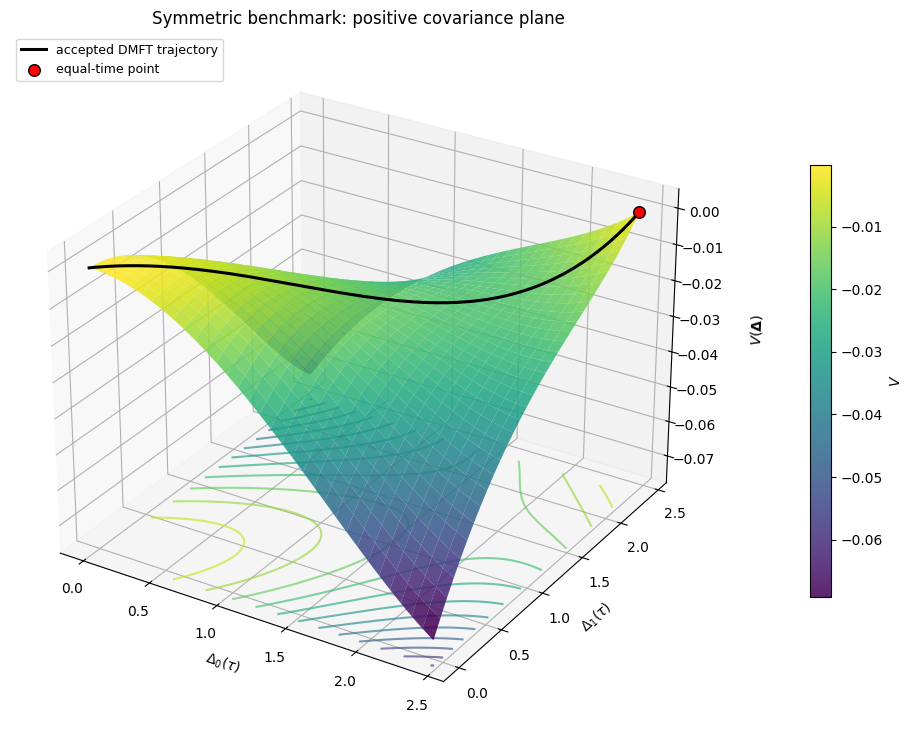

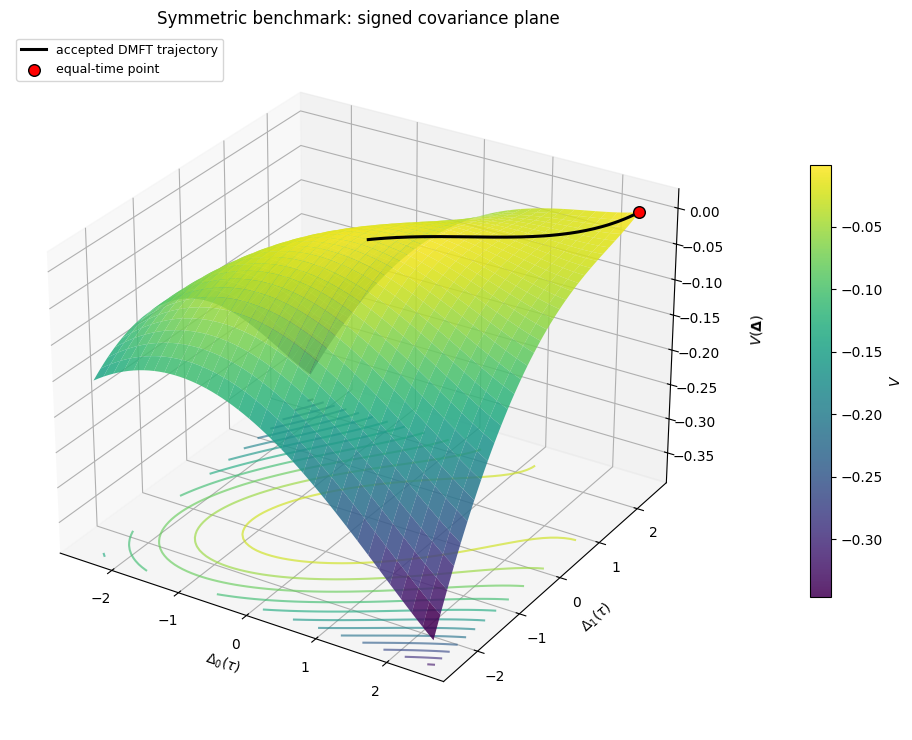

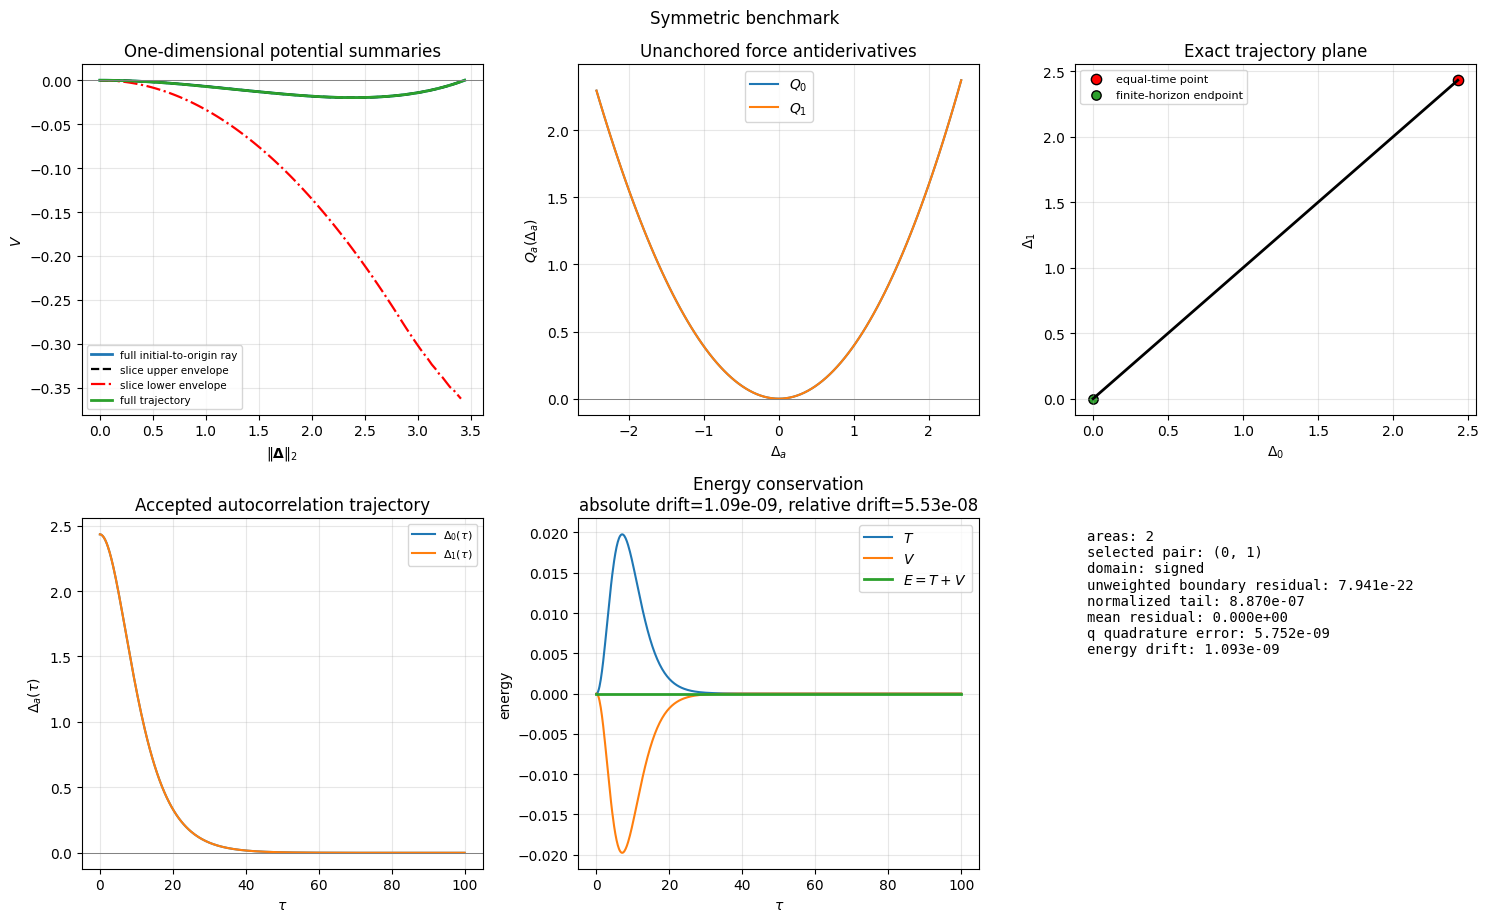

In [9]:
p_sym = example_two_area()
mu_scalar, Delta_scalar = symmetric_seed(to_dmft_params(p_sym), n_energy=120)
sol_sym = require_accepted(solve_landing(p_sym, Delta_scalar, mu_scalar))
np.testing.assert_allclose(sol_sym['mu'], mu_scalar, rtol=1e-5, atol=1e-7)
np.testing.assert_allclose(sol_sym['Delta0'], Delta_scalar, rtol=1e-5, atol=1e-7)
show_solution(sol_sym, 'Symmetric benchmark')
energy_sym = draw_energy_example(sol_sym, 'Symmetric benchmark')

## 10. Asymmetric two-area network

Keep \(J^{0\to1}=0.03\) and reduce \(J^{1\to0}\) to \(0.02\). Both directions
remain present, so an exact energy landscape exists even though the two covariance
trajectories and their equal-time variances differ. The landing conditions are solved
jointly; no per-area scalar energy update is used.

Asymmetric two-area network: accepted (2 areas)
 area          mu        <phi>       Delta0     active fraction
    0    0.427760    0.967694    0.570189          0.890397
    1    0.591478    1.139508    0.799101          0.888956
  mean_residual                   1.110e-16
  boundary_residual               1.482e-20
  ode_residual                    5.406e-07
  tail_norm                       1.405e-05
  box_excess                      0.000e+00
  kernel_interpolation_error      4.337e-07
  kernel_quadrature_error         2.914e-09
  kernel_origin_slope_error       5.312e-08
  covariance_min_eigenvalue       -2.917e-10
  refinement_change               1.781e-06
  refinement: horizon / kernel points / ODE residual / solution change
      67.20 /  401 / 1.45e-06 / inf
      84.00 /  801 / 5.41e-07 / 1.78e-06
  Covariance PSD checks sample two lag grids; they are not a continuum proof.
Asymmetric two-area network: eigenvalues of G = [0.54965599 1.23798598]
  V(Delta0)=-6.503e-11; energ

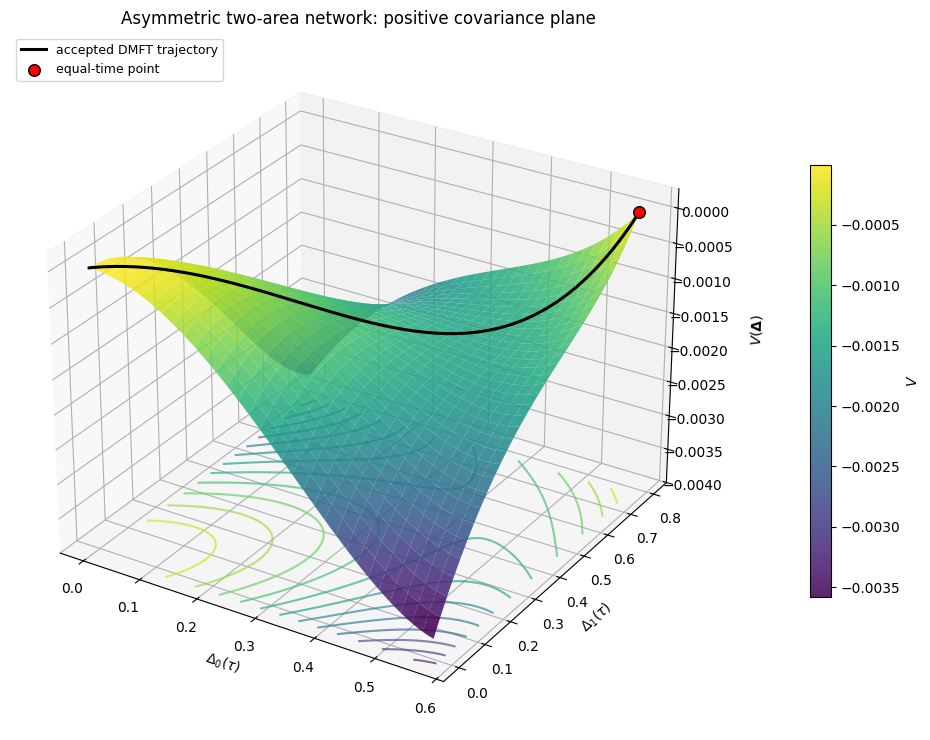

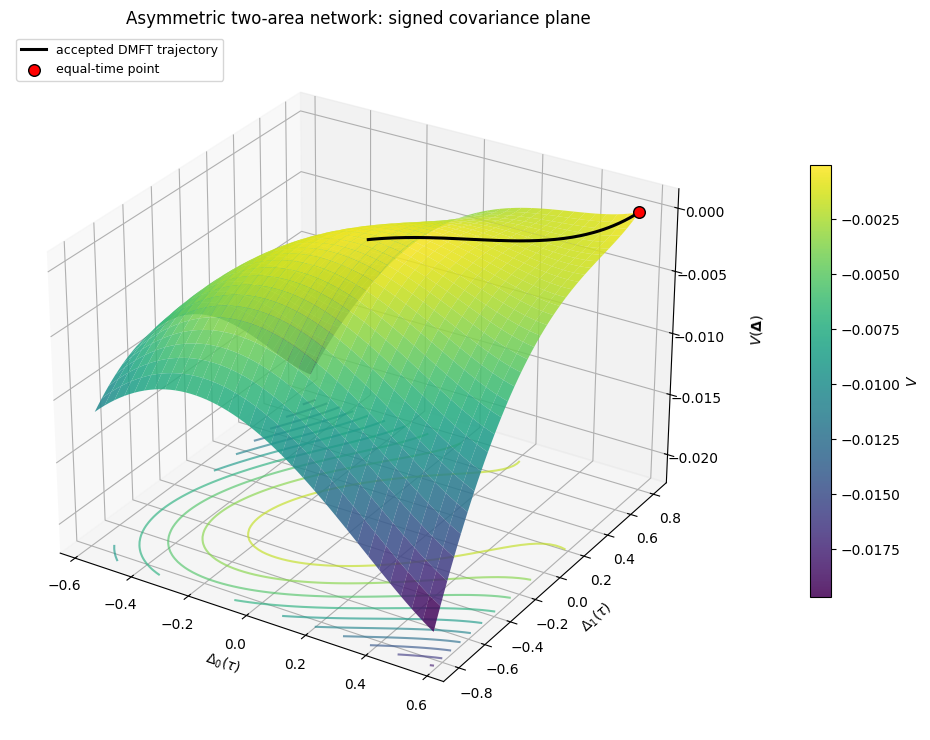

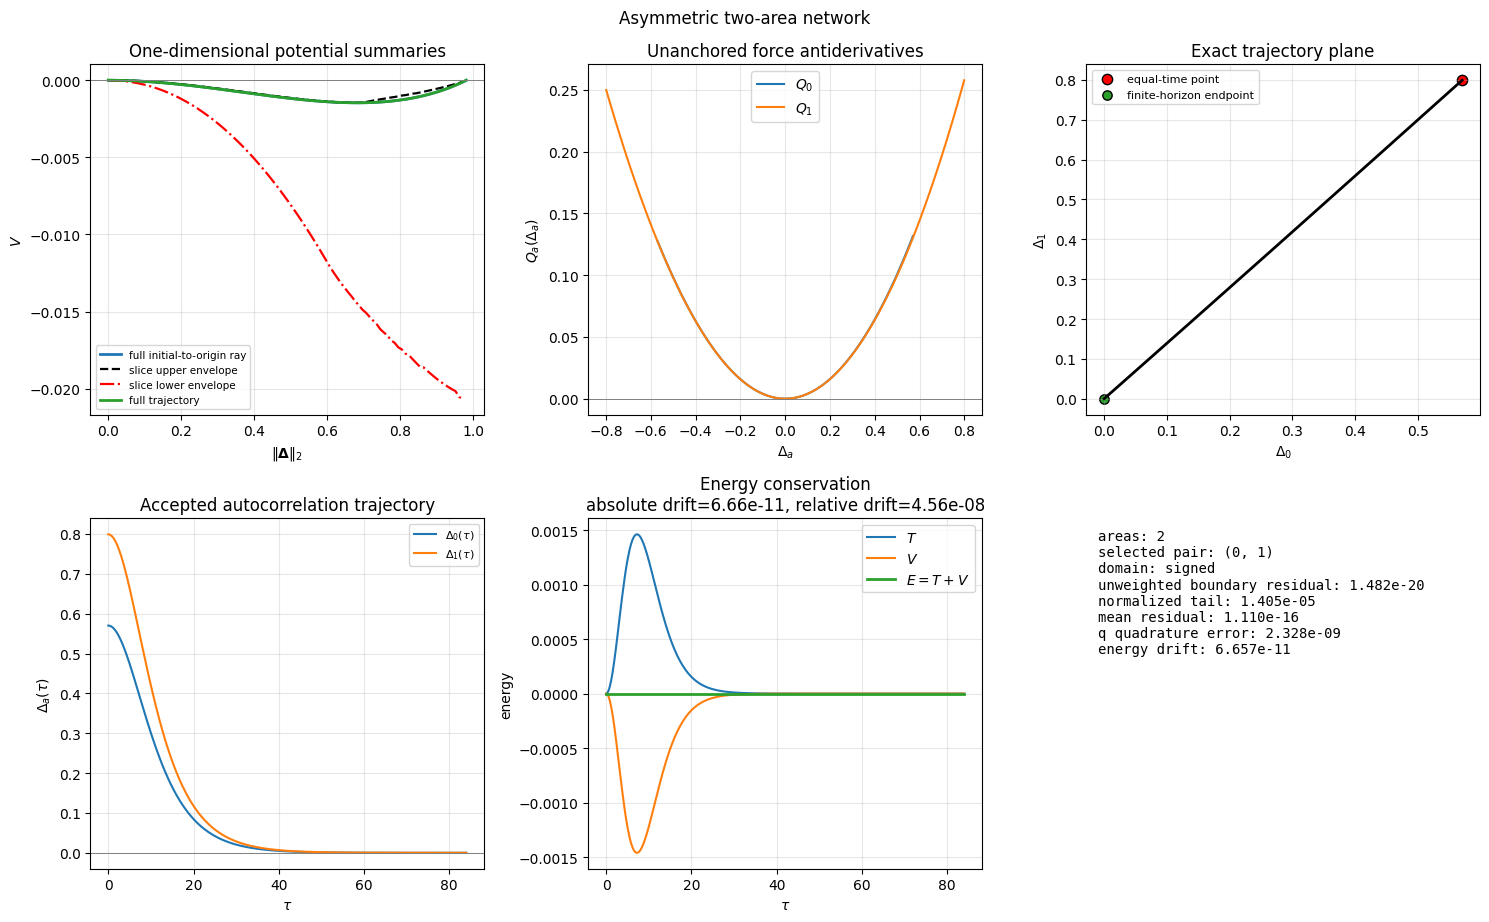

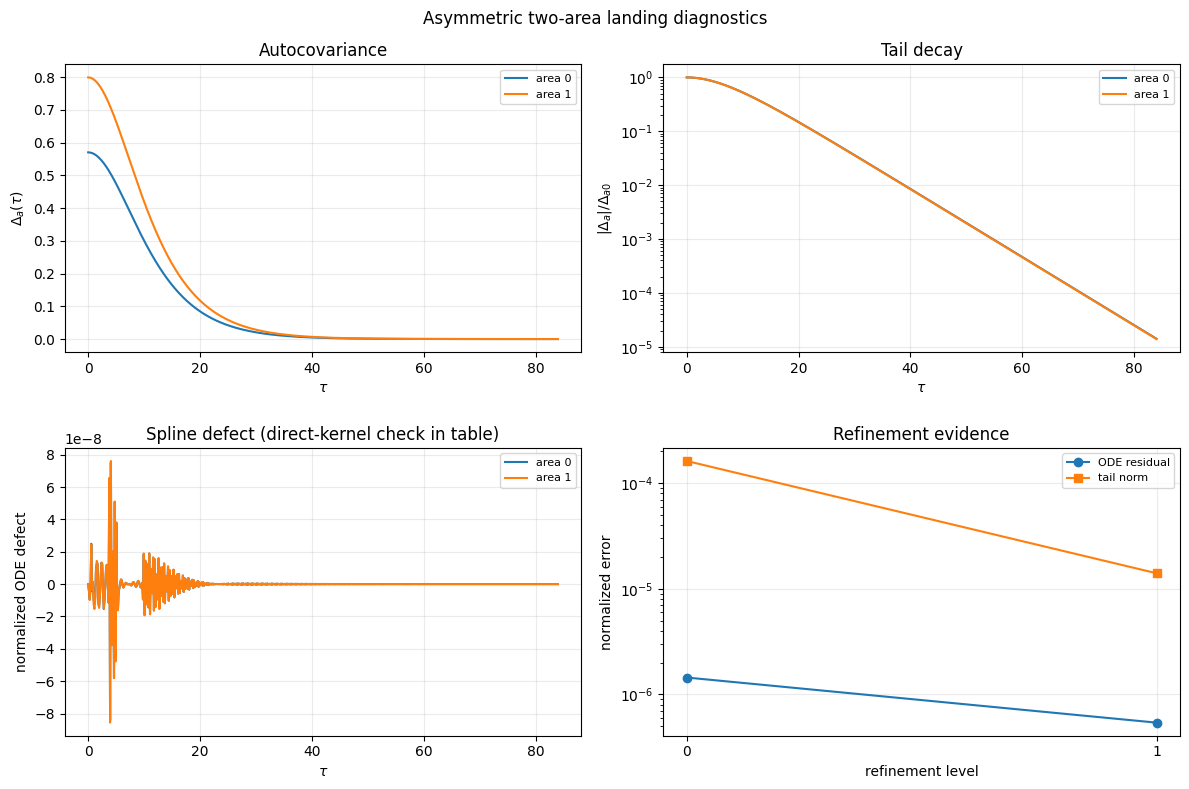

In [10]:
p_asym = example_two_area(J_return=.02)
path_asym = solve_landing_continuation([p_sym, p_asym],
    mu_seed=sol_sym['mu'], Delta0_seed=sol_sym['Delta0'])
sol_asym = require_accepted(path_asym[-1])
show_solution(sol_asym, 'Asymmetric two-area network')
energy_asym = draw_energy_example(sol_asym, 'Asymmetric two-area network')
plot_landing_diagnostics(sol_asym, 'Asymmetric two-area landing diagnostics')
plt.show()

## 11. Bounded activation

Repeat the symmetric-to-asymmetric path with \(\phi_{\max}=5\). The cap has a visible
effect on the symmetric benchmark's variance, but little effect at the weaker asymmetric
endpoint, where saturation is rare. This is a separate branch solve, not a clipped
unbounded solution.

Bounded symmetric seed: accepted (2 areas)
 area          mu        <phi>       Delta0     active fraction
    0    1.311303    1.873289    2.016313          0.886586
    1    1.311303    1.873289    2.016313          0.886586
  mean_residual                   1.693e-16
  boundary_residual               5.029e-22
  ode_residual                    5.862e-07
  tail_norm                       7.615e-07
  box_excess                      0.000e+00
  kernel_interpolation_error      4.620e-07
  kernel_quadrature_error         2.713e-09
  kernel_origin_slope_error       9.149e-08
  covariance_min_eigenvalue       -2.146e-10
  refinement_change               1.935e-06
  refinement: horizon / kernel points / ODE residual / solution change
      87.90 /  401 / 1.66e-06 / inf
     109.88 /  801 / 5.86e-07 / 1.93e-06
  Covariance PSD checks sample two lag grids; they are not a continuum proof.
Bounded asymmetric network: accepted (2 areas)
 area          mu        <phi>       Delta0     active frac

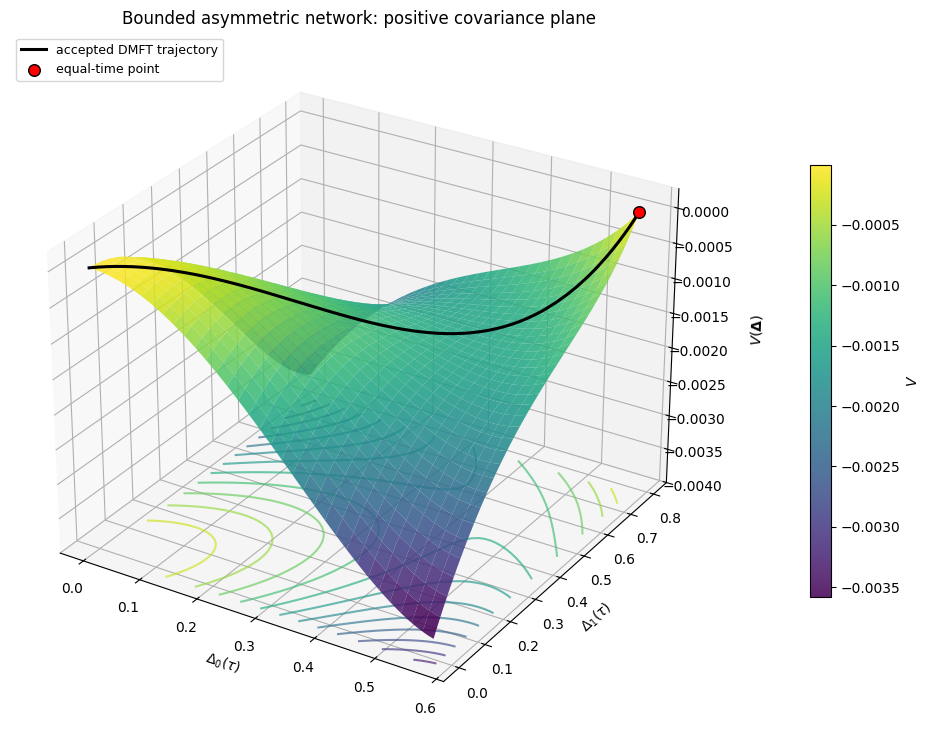

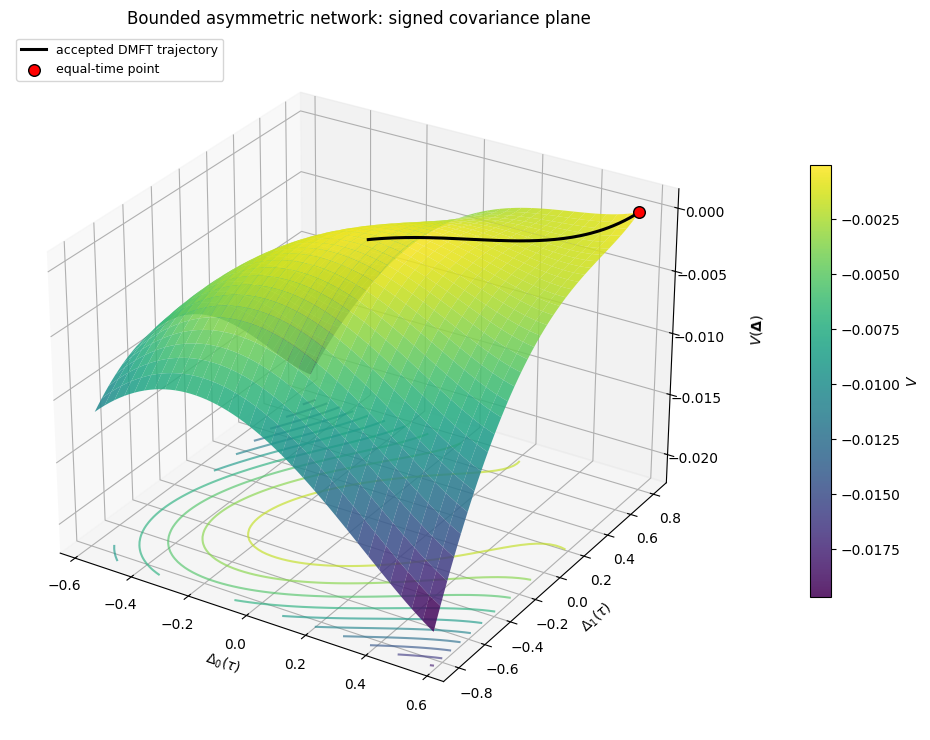

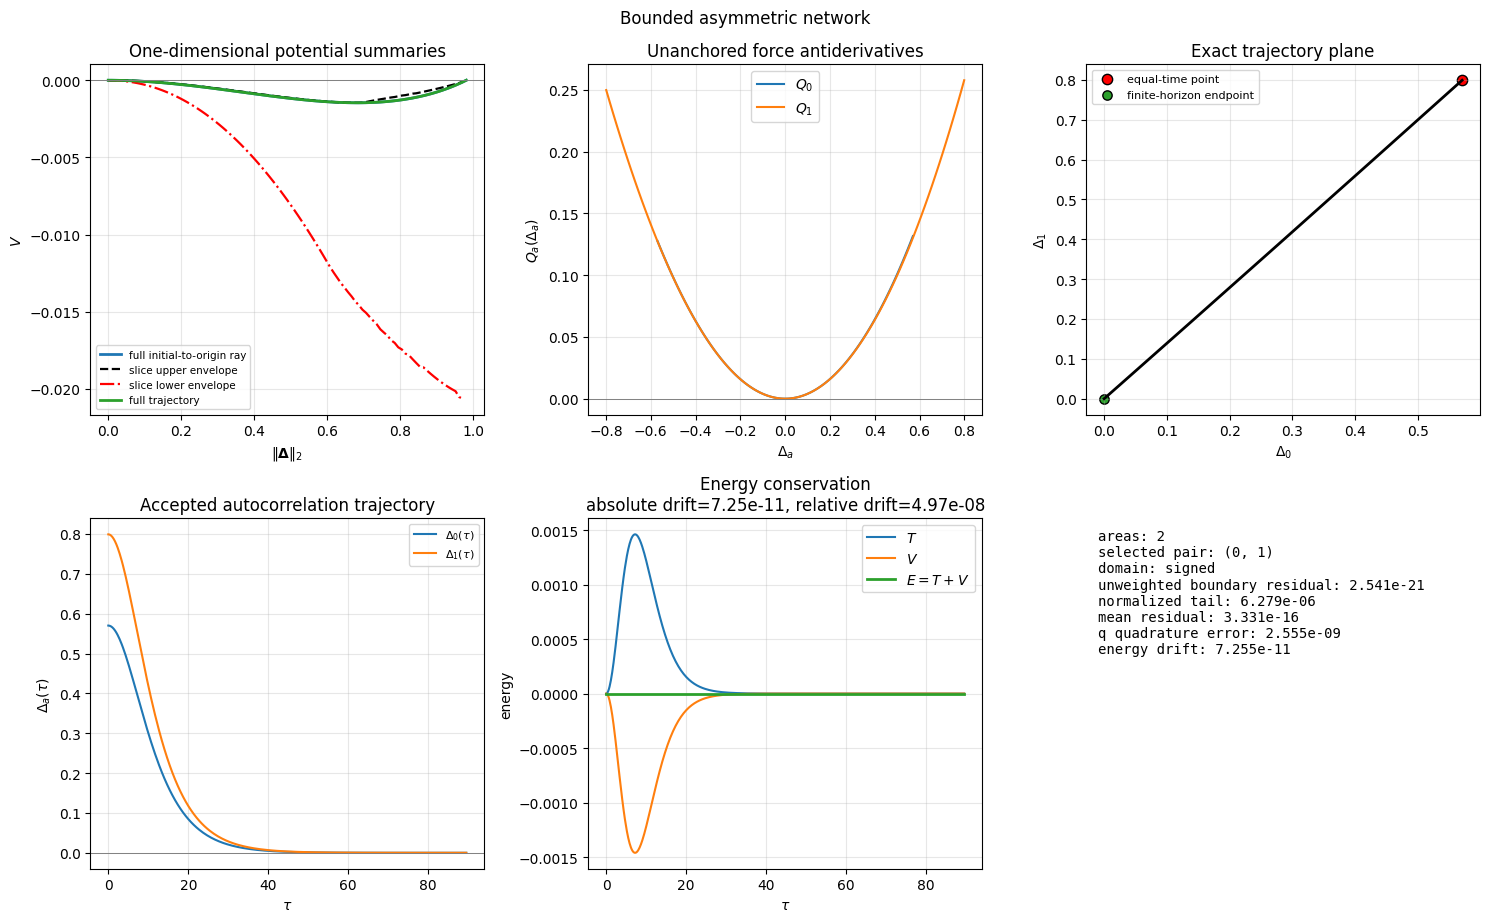

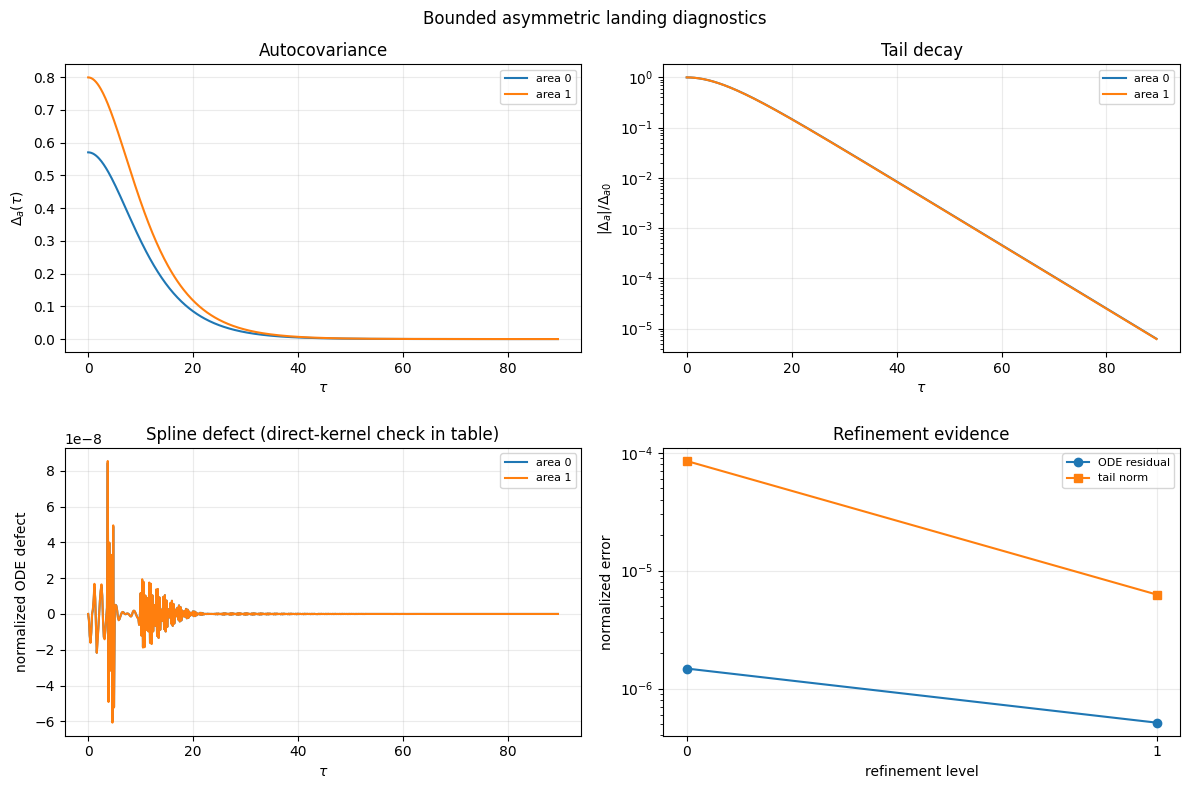

In [11]:
path_bounded = solve_landing_continuation([
    example_two_area(phi_max=5.), example_two_area(J_return=.02, phi_max=5.)])
sol_bounded_sym, sol_bounded = path_bounded[0], require_accepted(path_bounded[-1])
show_solution(sol_bounded_sym, 'Bounded symmetric seed')
show_solution(sol_bounded, 'Bounded asymmetric network')
energy_bounded = draw_energy_example(sol_bounded, 'Bounded asymmetric network')
plot_landing_diagnostics(sol_bounded, 'Bounded asymmetric landing diagnostics')
plt.show()

## 12. Heterogeneous directed three-area network

Start with three identical areas and equal incoming row sums. Continue to a directed
cycle \(0\to1\to2\to0\), with within-area weights \((0.055,0.057,0.059)\),
cross-area weights \((0.070,0.065,0.075)\), five source excitatory inputs per projection,
and drives \((0,0.02,-0.01)\). The final row sums differ, so it cannot use the equal-area
scalar reduction. Its one-way edges prohibit the diagonal energy construction.

The attempted large continuation steps may leave the admissible spectral branch;
adaptive subdivision retains these failures and reaches the requested endpoint.

Directed three-area network: accepted (3 areas)
 area          mu        <phi>       Delta0     active fraction
    0   -0.084875    0.472029    0.249784          0.796903
    1   -0.091096    0.484747    0.313019          0.767569
    2   -0.127382    0.465975    0.343950          0.737401
  mean_residual                   4.684e-17
  boundary_residual               2.197e-25
  ode_residual                    4.486e-07
  tail_norm                       1.958e-10
  box_excess                      0.000e+00
  kernel_interpolation_error      2.642e-07
  kernel_quadrature_error         3.239e-09
  kernel_origin_slope_error       1.026e-08
  covariance_min_eigenvalue       -5.811e-11
  refinement_change               3.957e-07
  refinement: horizon / kernel points / ODE residual / solution change
      62.78 /  401 / 3.54e-06 / inf
      78.48 /  801 / 1.26e-06 / 1.56e-06
      98.10 / 1601 / 4.49e-07 / 3.96e-07
  Covariance PSD checks sample two lag grids; they are not a continuum proof.


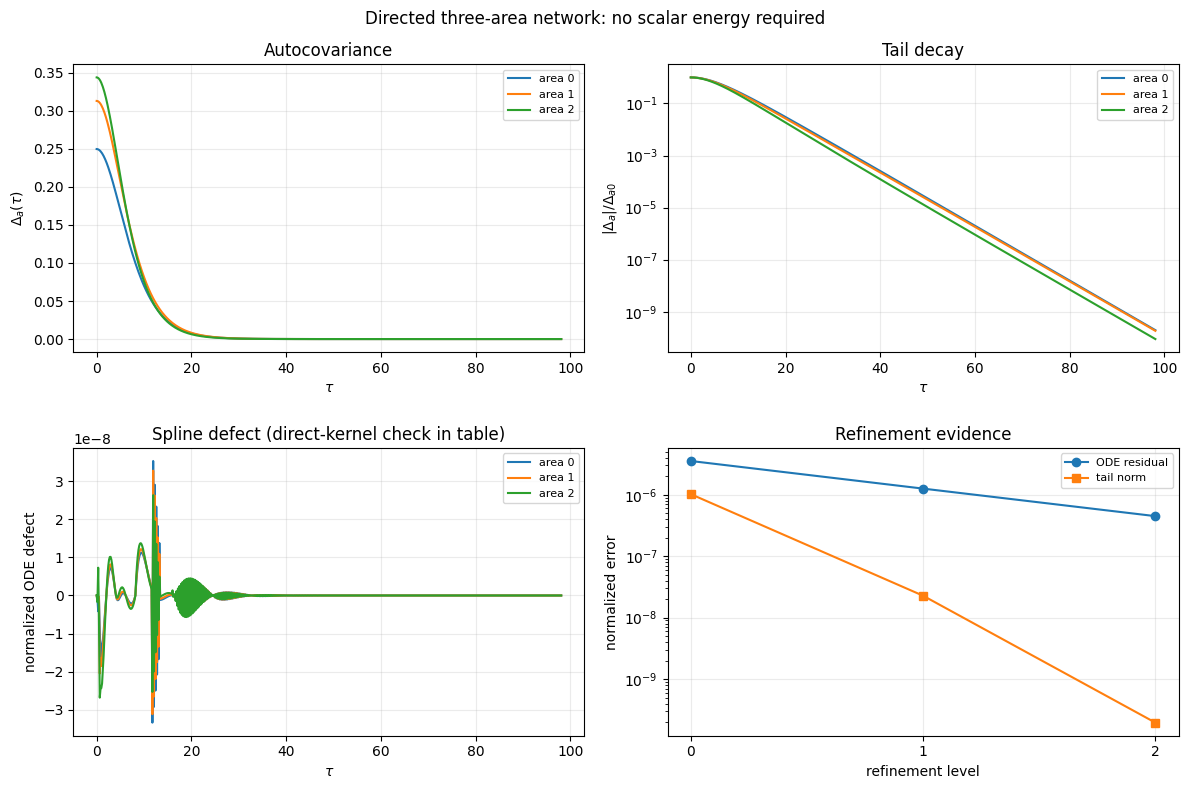

In [12]:
a3 = AreaParams(J_exc=.055)
s3 = (np.ones((3, 3))-np.eye(3))*.00625
j3 = (np.ones((3, 3))-np.eye(3))*.035
p_three_seed = MultiAreaParams((a3, a3, a3), s3, j3, np.zeros(3))
p_three = MultiAreaParams(tuple(AreaParams(J_exc=w) for w in (.055, .057, .059)),
    s3, np.array([[0., .070, 0.], [0., 0., .065], [.075, 0., 0.]]),
    np.array([0., .02, -.01]))
path_three = solve_landing_continuation([p_three_seed, p_three])
sol_three = require_accepted(path_three[-1])
show_solution(sol_three, 'Directed three-area network')
print('Continuation attempts:')
for attempt in sol_three['continuation_history']:
    print(f"  target={attempt['target_index']}, subdivision={attempt['depth']}: {attempt['status']}")
assert_raises(ValueError, lambda: compute_D_G(sol_three['params'].M_random))
draw_energy_example(sol_three, 'Directed three-area network')
plot_landing_diagnostics(sol_three, 'Directed three-area network: no scalar energy required')
plt.show()

## 13. End-to-end numerical regression checks

Compare area relabeling, an independent short forward integration, scalar symmetry,
energy identities, and recorded refinement results. Deliberately invalid or unresolved
cases must not be accepted or labeled divergence. Results below are produced by this
execution, not hard-coded target statistics.

In [13]:
# Area permutation must permute the solution without changing its content.
perm = np.array([2, 0, 1])
p = sol_three['params']
p_permuted = DMFTParams(p.M_structure[np.ix_(perm, perm)],
    p.M_random[np.ix_(perm, perm)], p.I_ext[perm], p.gamma, p.phi_max)
permuted = require_accepted(solve_landing(p_permuted,
    sol_three['Delta0'][perm], sol_three['mu'][perm]))
np.testing.assert_allclose(permuted['mu'], sol_three['mu'][perm], rtol=1e-5, atol=1e-7)
np.testing.assert_allclose(permuted['Delta0'], sol_three['Delta0'][perm], rtol=1e-5, atol=1e-7)
lag = np.linspace(0, min(permuted['T'], sol_three['T']), 201)
np.testing.assert_allclose(permuted['trajectory'].sol(lag)[:3],
    sol_three['trajectory'].sol(lag)[perm], rtol=1e-4, atol=1e-6)

# Forward integration is meaningful over a short interval, never an acceptance test.
shoot = solve_landing(sol_asym['params'], sol_asym['Delta0'], sol_asym['mu'],
                      T=2., n_qgrid=1601, backend='shooting')
assert shoot['valid'] and not shoot['converged'] and shoot['status'] == 'diagnostic_only'
np.testing.assert_allclose(shoot['trajectory'].y,
    sol_asym['trajectory'].sol(shoot['trajectory'].t), rtol=1e-4, atol=2e-6)

# The energy gradient must reproduce the full vector force, independently of landing.
for result in (sol_sym, sol_asym, sol_bounded):
    model = build_energy_model(result)
    x = result['Delta0']*.4
    h = result['Delta0']*1e-5
    numerical_gradient = np.array([(model.potential(x+np.eye(len(x))[i]*h[i])
        -model.potential(x-np.eye(len(x))[i]*h[i]))/(2*h[i]) for i in range(len(x))])
    q = np.array([f(z) for f, z in zip(result['q_interpolators'], x)])
    np.testing.assert_allclose(numerical_gradient,
        -model.G@(x-result['params'].M_random@q), atol=2e-8, rtol=1e-6)
    energy = trajectory_energy(result, model)
    assert energy['relative_drift'] < 1e-4
    scale = max(np.max(np.abs(energy['V'])), np.max(np.abs(energy['T'])), 1e-12)
    assert abs(energy['V'][0])/scale < 1e-4

for result in (sol_sym, sol_asym, sol_bounded_sym, sol_bounded, sol_three, permuted):
    assert result['converged'] and all(result['checks'].values())
    assert len(result['refinement_history']) >= 2
    assert result['refinement_history'][-1]['T'] > result['refinement_history'][0]['T']
    assert result['metrics']['refinement_change'] < 1e-4
np.testing.assert_allclose(sol_sym['trajectory'].y[0], sol_sym['trajectory'].y[1], atol=1e-8)
assert np.ptp(sol_asym['Delta0']) > .1
assert np.ptp(sol_three['Delta0']) > .05
assert any(a['depth'] > 0 for a in sol_three['continuation_history'])

trivial = solve_landing(sol_sym['params'], np.full(2, 1e-12), np.zeros(2))
assert not trivial['converged'] and trivial['status'] == 'trivial_branch'
unsupported = solve_landing(DMFTParams(np.zeros((1, 1)), np.array([[2.]]), np.array([10.])),
                            np.array([1e-3]), np.array([10.]))
assert not unsupported['converged'] and unsupported['status'] == 'unsupported_spectrum'
assert_raises(ValueError, lambda: solve_landing(sol_sym['params'], np.zeros(2), np.zeros(2)))
assert_raises(ValueError, lambda: symmetric_seed(sol_three['params']))
print('PASS: scalar benchmark, asymmetric continuation, bounded and directed networks,')
print('      area permutation, short shooting comparison, energy identities, refinement,')
print('      sampled covariance validity, and explicit rejected-branch statuses.')

PASS: scalar benchmark, asymmetric continuation, bounded and directed networks,
      area permutation, short shooting comparison, energy identities, refinement,
      sampled covariance validity, and explicit rejected-branch statuses.


## 14. Interpretation and controls

- **Accepted:** closure, ODE, boundary, tail, sampled covariance, and refinement checks all
  pass. Inspect `metrics` and `refinement_history` when comparing nearby parameter sets.
- **Unresolved:** `unsupported_spectrum`, `trivial_branch`, `variance_limit`,
  `seed_not_found`, `nonconverged`, or `validation_failed` identifies the numerical or branch
  limitation. A spectral rejection describes the current candidate, not every possible
  mean/variance branch of the network.
- **Accuracy:** increase `n_qgrid`, lower `bvp_tol` / `residual_tol`, or extend `max_T` and
  `max_refinements`. `T` is a minimum horizon. The reported quadrature error is an estimate;
  interpolation and direct-equation checks provide independent evidence.
- **Continuation:** `requested_target` distinguishes endpoints from inserted bridge points.
  Effective-matrix interpolation preserves nonnegative variance couplings, but does not
  preserve every microscopic connectivity constraint at intermediate points.
- **Scope:** nonzero long-lag plateaus, persistent oscillations, exhaustive coexisting-branch
  searches, and comparisons with finite random networks are outside this notebook.
  Negative covariance is not itself unphysical; the covariance bounds and PSD evidence
  matter. No landscape is fabricated for networks without a diagonal symmetrizer.